# Show, Attend and Tell: Neural Image Caption Generation with Visual Attention

**Authors:** Kelvin Xu, Jimmy Lei Ba, Ryan Kiros, Kyunghyun Cho, Aaron Courville, Ruslan Salakhutdinov, Richard S. Zemel, Yoshua Bengio
**Venue:** ICML 2015 (arXiv:1502.03044)

---

## Abstract

The paper introduces an attention-based encoder–decoder model for automatic image captioning. A convolutional network extracts a grid of spatially localized feature vectors, and an LSTM decoder generates the caption one word at a time. At each step, a learned attention mechanism selects or weights image regions relevant to the next word. The authors propose two variants within a common framework:

- A **stochastic "hard" attention** model, trained by maximizing a variational lower bound on the log-likelihood (equivalent to REINFORCE).
- A **deterministic "soft" attention** model, trained end-to-end with standard backpropagation.

The model achieves state-of-the-art BLEU and METEOR scores on Flickr8k, Flickr30k, and MS COCO. Visualizing the attention weights shows that the model learns, without supervision, to fix its gaze on salient objects as it generates the corresponding words.

---

## Problems

1. **Information bottleneck in prior captioning models.** Earlier neural captioners (e.g., Google NIC, LRCN, m-RNN) compressed the whole image into a single vector from the top fully connected layer of a CNN. This static representation discards spatial and fine-grained information that could support richer, more descriptive captions.
2. **No mechanism for selective focus.** Lower-level convolutional features preserve more information, but using them requires a way to steer the decoder toward the regions relevant at each generation step.
3. **Reliance on explicit object detectors.** Alignment-based approaches (e.g., Karpathy & Li, Fang et al.) depend on pre-trained object detectors. This restricts what the model can align to ("objectness") and adds pipeline complexity.
4. **Limited interpretability.** Single-vector models give no insight into which visual evidence produced each word.

---

## Proposed Solutions

| Component | Proposal |
|---|---|
| Encoder | Use features from a lower convolutional layer (a spatial grid of annotation vectors), not a fully connected layer |
| Attention | An MLP, conditioned on the previous decoder state, scores each image location at every time step |
| Hard attention | Sample a single location from a multinoulli distribution and train with a variational bound / REINFORCE |
| Soft attention | Compute the expected context vector as a weighted sum of all locations and train with backpropagation |
| Regularization | Doubly stochastic attention penalty and a learned gating scalar $$\beta$$ |
| Interpretability | Upsample and visualize the attention weights over the image for each generated word |

---

## Purpose

The study aims to show that a visual attention mechanism, inspired by human visual attention and by attention in neural machine translation (Bahdanau et al., 2014), can:

- Improve caption quality over single-vector encoder–decoder models.
- Learn latent word–region alignments from scratch, without object detectors, including alignment to non-object regions.
- Make the generation process interpretable by revealing "where" and "what" the model attends to.
- Provide a unified framework comparing stochastic (hard) and deterministic (soft) attention.

---

## Methodology

### 1. Encoder: Convolutional Annotation Vectors

A VGG-19 network (Oxford VGGnet), pre-trained on ImageNet and not fine-tuned, extracts the $$14 \times 14 \times 512$$ feature map of the fourth convolutional block before max pooling. This map is flattened into $$L = 196$$ annotation vectors of dimension $$D = 512$$:

$$
a = \{\mathbf{a}_1, \dots, \mathbf{a}_L\}, \quad \mathbf{a}_i \in \mathbb{R}^D
$$

The caption is a sequence of 1-of-$$K$$ encoded words:

$$
y = \{\mathbf{y}_1, \dots, \mathbf{y}_C\}, \quad \mathbf{y}_i \in \mathbb{R}^K
$$

### 2. Decoder: LSTM

The LSTM is conditioned on the embedded previous word, the previous hidden state, and the context vector $$\hat{\mathbf{z}}_t$$:

$$
\begin{pmatrix} \mathbf{i}_t \\ \mathbf{f}_t \\ \mathbf{o}_t \\ \mathbf{g}_t \end{pmatrix}
=
\begin{pmatrix} \sigma \\ \sigma \\ \sigma \\ \tanh \end{pmatrix}
T_{D+m+n,\,n}
\begin{pmatrix} E\mathbf{y}_{t-1} \\ \mathbf{h}_{t-1} \\ \hat{\mathbf{z}}_t \end{pmatrix}
$$

$$
\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \mathbf{g}_t, \qquad
\mathbf{h}_t = \mathbf{o}_t \odot \tanh(\mathbf{c}_t)
$$

The initial states are predicted from the mean annotation vector through two separate MLPs:

$$
\mathbf{c}_0 = f_{\text{init},c}\left(\frac{1}{L}\sum_{i=1}^{L}\mathbf{a}_i\right), \qquad
\mathbf{h}_0 = f_{\text{init},h}\left(\frac{1}{L}\sum_{i=1}^{L}\mathbf{a}_i\right)
$$

A deep output layer computes the word distribution:

$$
p(\mathbf{y}_t \mid a, \mathbf{y}_1^{t-1}) \propto \exp\left(L_o(E\mathbf{y}_{t-1} + L_h\mathbf{h}_t + L_z\hat{\mathbf{z}}_t)\right)
$$

### 3. Attention Mechanism

An MLP $$f_{\text{att}}$$ scores each location, and a softmax normalizes the scores:

$$
e_{ti} = f_{\text{att}}(\mathbf{a}_i, \mathbf{h}_{t-1}), \qquad
\alpha_{ti} = \frac{\exp(e_{ti})}{\sum_{k=1}^{L}\exp(e_{tk})}
$$

$$
\hat{\mathbf{z}}_t = \phi\left(\{\mathbf{a}_i\}, \{\alpha_{ti}\}\right)
$$

The two variants differ only in the definition of $$\phi$$.

### 4. Stochastic "Hard" Attention

The attended location $$s_t$$ is a one-hot latent variable drawn from a multinoulli distribution:

$$
p(s_{t,i} = 1 \mid s_{j<t}, a) = \alpha_{t,i}, \qquad
\hat{\mathbf{z}}_t = \sum_i s_{t,i}\,\mathbf{a}_i
$$

Training maximizes a variational lower bound on the marginal log-likelihood:

$$
L_s = \sum_s p(s \mid a)\log p(\mathbf{y} \mid s, a) \le \log p(\mathbf{y} \mid a)
$$

The gradient is estimated by Monte Carlo sampling, $$\tilde{s}_t \sim \text{Multinoulli}_L(\{\alpha_i\})$$, with variance reduction:

- A moving-average baseline: $$b_k = 0.9\, b_{k-1} + 0.1 \log p(\mathbf{y} \mid \tilde{s}_k, a)$$
- An entropy regularizer $$H[s]$$ on the attention distribution.
- With probability 0.5, the sampled location is replaced by its expected value $$\alpha$$.

The final learning rule, equivalent to REINFORCE:

$$
\frac{\partial L_s}{\partial W} \approx \frac{1}{N}\sum_{n=1}^{N}\left[
\frac{\partial \log p(\mathbf{y} \mid \tilde{s}^n, a)}{\partial W}
+ \lambda_r\left(\log p(\mathbf{y} \mid \tilde{s}^n, a) - b\right)\frac{\partial \log p(\tilde{s}^n \mid a)}{\partial W}
+ \lambda_e \frac{\partial H[\tilde{s}^n]}{\partial W}
\right]
$$

### 5. Deterministic "Soft" Attention

Instead of sampling, the model uses the expected context vector, making the whole system differentiable:

$$
\mathbb{E}_{p(s_t \mid a)}[\hat{\mathbf{z}}_t] = \sum_{i=1}^{L}\alpha_{t,i}\,\mathbf{a}_i
$$

The authors justify this theoretically: using the normalized weighted geometric mean (NWGM) of the softmax, a single forward pass with the expected context vector approximates the expectation over all attention locations. Soft attention is therefore an approximation to marginalizing over $$s_t$$.

**Doubly stochastic regularization.** Since $$\sum_i \alpha_{ti} = 1$$ by construction, the model also encourages $$\sum_t \alpha_{ti} \approx 1$$, so every region receives attention over the course of generation. A gating scalar $$\beta_t = \sigma(f_\beta(\mathbf{h}_{t-1}))$$ scales the context vector, $$\phi = \beta_t\sum_i \alpha_{ti}\mathbf{a}_i$$. The training objective is:

$$
L_d = -\log P(\mathbf{y} \mid \mathbf{x}) + \lambda\sum_{i=1}^{L}\left(1 - \sum_{t=1}^{C}\alpha_{ti}\right)^2
$$

### 6. Experimental Setup

| Setting | Value |
|---|---|
| Datasets | Flickr8k (8,000 images), Flickr30k (30,000), MS COCO (82,783) |
| References per image | 5 (extra COCO references discarded) |
| Vocabulary size | 10,000 |
| Optimizers | RMSProp (Flickr8k), Adam (Flickr30k, COCO) |
| Batching | Mini-batches of 64 captions grouped by sentence length |
| Regularization | Dropout and early stopping on validation BLEU |
| Hyperparameter search | Whetlab (Bayesian optimization) on Flickr8k |
| Metrics | BLEU-1 to BLEU-4 (no brevity penalty), METEOR |
| Compute | Soft model trained in under 3 days on COCO with one NVIDIA Titan Black |
| Framework | Theano |

All results are from single models (no ensembles), compared only against methods using comparable GoogLeNet or VGG features where possible, on publicly available splits (Karpathy & Li) for Flickr30k and COCO.

---

## Results

### Quantitative Results (selected)

| Dataset | Model | BLEU-1 | BLEU-2 | BLEU-3 | BLEU-4 | METEOR |
|---|---|---|---|---|---|---|
| Flickr8k | Google NIC (ensemble) | 63.0 | 41.0 | 27.0 | — | — |
| Flickr8k | Log Bilinear | 65.6 | 42.4 | 27.7 | 17.7 | 17.31 |
| Flickr8k | **Soft-Attention** | 67.0 | 44.8 | 29.9 | 19.5 | 18.93 |
| Flickr8k | **Hard-Attention** | **67.0** | **45.7** | **31.4** | **21.3** | **20.30** |
| Flickr30k | Google NIC (ensemble) | 66.3 | 42.3 | 27.7 | 18.3 | — |
| Flickr30k | **Soft-Attention** | 66.7 | 43.4 | 28.8 | 19.1 | **18.49** |
| Flickr30k | **Hard-Attention** | **66.9** | **43.9** | **29.6** | **19.9** | 18.46 |
| COCO | Google NIC (ensemble) | 66.6 | 46.1 | 32.9 | 24.6 | — |
| COCO | Log Bilinear | 70.8 | 48.9 | 34.4 | 24.3 | 20.03 |
| COCO | **Soft-Attention** | 70.7 | 49.2 | 34.4 | 24.3 | **23.90** |
| COCO | **Hard-Attention** | **71.8** | **50.4** | **35.7** | **25.0** | 23.04 |

### Key Findings

1. **State-of-the-art performance** on all three benchmarks using a single model, outperforming ensembled baselines.
2. **Hard attention** achieves the best BLEU scores on all datasets; **soft attention** achieves the best METEOR on Flickr30k and COCO.
3. **Large METEOR gain on COCO** (23.90 versus 20.41 for the strongest prior result), which the authors attribute to the doubly stochastic regularization and the use of lower-level convolutional features.
4. **Doubly stochastic regularization** improved BLEU and produced richer, more descriptive captions.
5. **Qualitative alignment.** Attention maps, upsampled by a factor of 16 and smoothed with a Gaussian filter, align closely with human intuition (e.g., "frisbee", "dog", "stop sign"). The model also attends to non-object regions such as "water" or "background".
6. **Error diagnosis.** In failure cases (e.g., a giraffe captioned as a "bird", a violin as a "skateboard"), the attention maps reveal which visual evidence misled the model.
7. **Hard versus soft behavior.** Hard attention produces sharp, localized foci; soft attention produces diffuse, weighted maps.

---

## Conclusions

- Attention over spatially localized convolutional features significantly improves neural image captioning compared to compressing the image into a single vector.
- Both stochastic hard attention (variational bound / REINFORCE) and deterministic soft attention (backpropagation) are effective under one framework. Soft attention can be interpreted as an approximation to marginalizing over attention locations.
- The model learns meaningful word–region alignments without explicit object detectors and can attend beyond objects to abstract or contextual regions.
- Attention adds interpretability, enabling visualization of the model's focus and analysis of its errors.
- The modular encoder–decoder design with attention generalizes beyond captioning. The paper became a foundational reference for visual attention in multimodal learning, influencing later work in visual question answering, image-to-text generation, and attention-based vision–language architectures.

# Mathematical and Statistical Content: Show, Attend and Tell

---

## 1. Notation and Data Representation

### 1.1 Caption as a Sequence of One-Hot Vectors

$$
y = \{\mathbf{y}_1, \dots, \mathbf{y}_C\}, \quad \mathbf{y}_i \in \mathbb{R}^K
$$

- **Meaning:** A caption of $C$ words, where each word is a vector of length $K$ (the vocabulary size) with a single 1 at the word's index and 0 elsewhere ("1-of-$K$" encoding).
- **Role:** This is the target output the model learns to generate. In the experiments, $K = 10{,}000$.

### 1.2 Annotation Vectors (Image Features)

$$
a = \{\mathbf{a}_1, \dots, \mathbf{a}_L\}, \quad \mathbf{a}_i \in \mathbb{R}^D
$$

- **Meaning:** The image is described by $L$ feature vectors, each of dimension $D$, each tied to one spatial region of the image.
- **Role:** These are the candidate regions that attention chooses among. VGG produces a $14 \times 14 \times 512$ feature map, flattened to $L = 196$ vectors of size $D = 512$.

| Quantity | Symbol | Value |
|---|---|---|
| Spatial grid | $14 \times 14$ | 196 regions |
| Number of regions | $L$ | 196 |
| Feature dimension | $D$ | 512 |
| Vocabulary size | $K$ | 10,000 |
| Encoder matrix | $L \times D$ | $196 \times 512$ |

### 1.3 Affine Transformation

$$
T_{s,t} : \mathbb{R}^s \to \mathbb{R}^t, \qquad T_{s,t}(\mathbf{x}) = W\mathbf{x} + \mathbf{b}
$$

- **Meaning:** A learned linear map plus bias (a fully connected layer without activation). It maps an $s$-dimensional input to a $t$-dimensional output.
- **Role:** The building block of all gates in the LSTM. Bias terms are omitted in the paper's equations for readability.

### 1.4 Word Embedding Matrix

$$
E \in \mathbb{R}^{m \times K}, \qquad E\mathbf{y}_{t-1} \in \mathbb{R}^{m}
$$

- **Meaning:** Multiplying a one-hot vector by $E$ selects one column, giving a dense $m$-dimensional vector for that word.
- **Role:** Converts the previously generated word into a continuous input for the decoder.

---

## 2. The LSTM Decoder

### 2.1 Gate Computations

$$
\begin{pmatrix} \mathbf{i}_t \\ \mathbf{f}_t \\ \mathbf{o}_t \\ \mathbf{g}_t \end{pmatrix}
=
\begin{pmatrix} \sigma \\ \sigma \\ \sigma \\ \tanh \end{pmatrix}
T_{D+m+n,\,n}
\begin{pmatrix} E\mathbf{y}_{t-1} \\ \mathbf{h}_{t-1} \\ \hat{\mathbf{z}}_t \end{pmatrix}
$$

- **Meaning:** The previous word embedding ($m$ dims), previous hidden state ($n$ dims), and visual context ($D$ dims) are concatenated into one vector of size $D + m + n$. An affine map produces four vectors, each passed through its own activation:
  - $\mathbf{i}_t$: input gate (how much new information to write)
  - $\mathbf{f}_t$: forget gate (how much old memory to keep)
  - $\mathbf{o}_t$: output gate (how much memory to expose)
  - $\mathbf{g}_t$: input modulator (the candidate new content)
- **Activations:**

$$
\sigma(x) = \frac{1}{1 + e^{-x}} \in (0, 1), \qquad \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} \in (-1, 1)
$$

  The sigmoid outputs act as "soft switches" between 0 (closed) and 1 (open); $\tanh$ produces signed content.

### 2.2 Memory and Hidden State Updates

$$
\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \mathbf{g}_t
$$

$$
\mathbf{h}_t = \mathbf{o}_t \odot \tanh(\mathbf{c}_t)
$$

- **Meaning:** $\odot$ is element-wise multiplication. The new memory keeps a gated fraction of the old memory and adds a gated amount of new content. The hidden state is a gated, squashed view of memory.
- **Role:** The additive memory update lets information and gradients flow across many time steps, so the decoder can remember earlier words in the caption.

### 2.3 Initial States from the Mean Feature

$$
\mathbf{c}_0 = f_{\text{init},c}\left(\frac{1}{L}\sum_{i=1}^{L}\mathbf{a}_i\right), \qquad
\mathbf{h}_0 = f_{\text{init},h}\left(\frac{1}{L}\sum_{i=1}^{L}\mathbf{a}_i\right)
$$

- **Meaning:** The arithmetic mean of all region features is a global summary of the image. Two separate MLPs map it to the initial memory and hidden state.
- **Role:** Gives the decoder a global view of the image before it starts generating words.

---

## 3. The Attention Mechanism

### 3.1 Alignment Scores

$$
e_{ti} = f_{\text{att}}(\mathbf{a}_i, \mathbf{h}_{t-1})
$$

- **Meaning:** A small MLP outputs a real-valued score for each region $i$ at time $t$, based on the region's features and what the decoder has generated so far.
- **Role:** Measures how relevant region $i$ is for predicting the next word. Because it depends on $\mathbf{h}_{t-1}$, where the model looks changes as the sentence progresses.

### 3.2 Softmax Normalization

$$
\alpha_{ti} = \frac{\exp(e_{ti})}{\sum_{k=1}^{L}\exp(e_{tk})}
$$

- **Meaning:** Converts raw scores into positive weights that sum to 1, forming a probability distribution over the $L$ regions.
- **Two interpretations:**
  - **Hard attention:** $\alpha_{ti}$ is the probability that region $i$ is the correct place to look.
  - **Soft attention:** $\alpha_{ti}$ is the relative importance of region $i$ in a weighted blend.

### 3.3 Context Vector

$$
\hat{\mathbf{z}}_t = \phi\left(\{\mathbf{a}_i\}, \{\alpha_{ti}\}\right)
$$

- **Meaning:** A function $\phi$ combines region features and weights into one $D$-dimensional vector.
- **Role:** This is the visual input to the LSTM at time $t$. The hard and soft variants differ only in how $\phi$ is defined.

---

## 4. Output Word Distribution

### 4.1 Deep Output Layer

$$
p(\mathbf{y}_t \mid a, \mathbf{y}_1^{t-1}) \propto \exp\left(L_o(E\mathbf{y}_{t-1} + L_h\mathbf{h}_t + L_z\hat{\mathbf{z}}_t)\right)
$$

with $L_o \in \mathbb{R}^{K \times m}$, $L_h \in \mathbb{R}^{m \times n}$, $L_z \in \mathbb{R}^{m \times D}$.

- **Meaning:** The previous word, current hidden state, and visual context are each projected into the same $m$-dimensional space, summed, then projected to $K$ scores (one per word). The symbol $\propto$ ("proportional to") means a softmax normalization over the vocabulary is applied.
- **Role:** Produces the probability of each vocabulary word as the next word.

### 4.2 Sentence Probability (Chain Rule)

Implicit in the model is the chain rule of probability:

$$
p(\mathbf{y} \mid a) = \prod_{t=1}^{C} p(\mathbf{y}_t \mid a, \mathbf{y}_1^{t-1})
\quad \Longrightarrow \quad
\log p(\mathbf{y} \mid a) = \sum_{t=1}^{C} \log p(\mathbf{y}_t \mid a, \mathbf{y}_1^{t-1})
$$

- **Role:** The caption's probability is the product of per-word probabilities. Training maximizes this log-likelihood (equivalently, minimizes the negative log-likelihood, i.e., cross-entropy).

---

## 5. Stochastic "Hard" Attention

### 5.1 Attention Location as a Latent Variable

$$
p(s_{t,i} = 1 \mid s_{j<t}, a) = \alpha_{t,i}, \qquad
\hat{\mathbf{z}}_t = \sum_i s_{t,i}\,\mathbf{a}_i
$$

- **Meaning:** $s_t$ is a one-hot vector that picks exactly one region. It follows a **multinoulli (categorical) distribution** with probabilities $\alpha_{t,i}$, i.e., a single roll of an $L$-sided weighted die. The sum then simply returns the chosen region's feature vector.
- **Role:** Models attention as a discrete decision, like a human eye fixating on one spot. Since $s_t$ is never observed in the data, it is a **latent variable**.

### 5.2 Variational Lower Bound

$$
L_s = \sum_s p(s \mid a)\log p(\mathbf{y} \mid s, a)
\;\le\; \log \sum_s p(s \mid a)\, p(\mathbf{y} \mid s, a)
\;=\; \log p(\mathbf{y} \mid a)
$$

- **Meaning:** The true objective $\log p(\mathbf{y} \mid a)$ requires summing over every possible sequence of attention locations ($L^C$ possibilities), which is intractable. The inequality follows from **Jensen's inequality**: because $\log$ is concave, the average of logs is at most the log of the average.
- **Role:** $L_s$ is a tractable **lower bound** on the log-likelihood. Pushing it up also pushes the true likelihood up.

### 5.3 Gradient of the Bound (Log-Derivative Trick)

$$
\frac{\partial L_s}{\partial W} = \sum_s p(s \mid a)\left[
\frac{\partial \log p(\mathbf{y} \mid s, a)}{\partial W}
+ \log p(\mathbf{y} \mid s, a)\,\frac{\partial \log p(s \mid a)}{\partial W}
\right]
$$

- **Meaning:** Derived with the product rule and the identity $\nabla p = p\,\nabla \log p$. The gradient has two parts:
  1. A standard term that improves word prediction given the chosen locations.
  2. A term that increases the probability of attention choices in proportion to how well they explained the caption.
- **Role:** The gradient is an expectation under $p(s \mid a)$, so it can be estimated by sampling.

### 5.4 Monte Carlo Estimation

$$
\tilde{s}_t \sim \text{Multinoulli}_L(\{\alpha_i\})
$$

$$
\frac{\partial L_s}{\partial W} \approx \frac{1}{N}\sum_{n=1}^{N}\left[
\frac{\partial \log p(\mathbf{y} \mid \tilde{s}^n, a)}{\partial W}
+ \log p(\mathbf{y} \mid \tilde{s}^n, a)\,\frac{\partial \log p(\tilde{s}^n \mid a)}{\partial W}
\right]
$$

- **Meaning:** Replace the exact expectation with an average over $N$ sampled attention sequences.
- **Role:** Makes training feasible. The estimate is unbiased but has **high variance**, which motivates the next three techniques.

### 5.5 Variance Reduction Techniques

**(a) Moving-Average Baseline**

$$
b_k = 0.9 \times b_{k-1} + 0.1 \times \log p(\mathbf{y} \mid \tilde{s}_k, a)
$$

- **Meaning:** An **exponential moving average** of recent log-likelihoods, where each new value contributes 10% and older values decay geometrically.
- **Role:** Subtracting $b$ from the reward turns it into "better or worse than usual". This centers the signal and reduces variance without introducing bias.

**(b) Entropy Regularization**

$$
H[s] = -\sum_{i=1}^{L}\alpha_i \log \alpha_i
$$

- **Meaning:** Entropy measures how spread out the attention distribution is (high when uniform, zero when all mass is on one region).
- **Role:** Rewarding entropy prevents attention from collapsing too early onto one region and encourages exploration.

**(c) Mixing with the Expected Value**

- With probability 0.5 per image, the sampled location $\tilde{s}$ is replaced by its expected value $\alpha$.
- **Role:** Mixes in low-variance deterministic updates, stabilizing training.

### 5.6 Final Learning Rule (REINFORCE)

$$
\frac{\partial L_s}{\partial W} \approx \frac{1}{N}\sum_{n=1}^{N}\left[
\frac{\partial \log p(\mathbf{y} \mid \tilde{s}^n, a)}{\partial W}
+ \lambda_r\left(\log p(\mathbf{y} \mid \tilde{s}^n, a) - b\right)\frac{\partial \log p(\tilde{s}^n \mid a)}{\partial W}
+ \lambda_e\,\frac{\partial H[\tilde{s}^n]}{\partial W}
\right]
$$

- **Meaning:** Combines the word-prediction gradient, the baseline-corrected policy gradient, and the entropy bonus. $\lambda_r$ and $\lambda_e$ are weighting hyperparameters chosen by cross-validation.
- **Interpretation:** This is the **REINFORCE** algorithm (Williams, 1992) from reinforcement learning. Attention choices are "actions", and the "reward" is the log-likelihood of the correct caption under those choices.

---

## 6. Deterministic "Soft" Attention

### 6.1 Expected Context Vector

$$
\mathbb{E}_{p(s_t \mid a)}[\hat{\mathbf{z}}_t] = \sum_{i=1}^{L}\alpha_{t,i}\,\mathbf{a}_i
$$

- **Meaning:** Instead of sampling one region, take the **expected value** of the context vector: a weighted average of all region features.
- **Role:** Everything becomes smooth and differentiable, so the model is trained end-to-end with ordinary backpropagation. No sampling or variance reduction is needed.

### 6.2 First-Order Taylor Approximation

- **Meaning:** The hidden state depends on $\hat{\mathbf{z}}_t$ through a linear projection followed by $\tanh$. A first-order Taylor expansion treats this function as approximately linear, so:

$$
\mathbb{E}[\mathbf{h}_t] \approx \mathbf{h}_t\big(\mathbb{E}[\hat{\mathbf{z}}_t]\big)
$$

- **Role:** Justifies computing a single forward pass with the expected context instead of averaging many passes.

### 6.3 Normalized Weighted Geometric Mean (NWGM)

Let $\mathbf{n}_t = L_o(E\mathbf{y}_{t-1} + L_h\mathbf{h}_t + L_z\hat{\mathbf{z}}_t)$, and let $n_{t,i}$ denote $\mathbf{n}_t$ computed with $\hat{\mathbf{z}}_t = \mathbf{a}_i$.

$$
\text{NWGM}[p(y_t = k \mid a)]
= \frac{\prod_i \exp(n_{t,k,i})^{p(s_{t,i}=1 \mid a)}}{\sum_j \prod_i \exp(n_{t,j,i})^{p(s_{t,i}=1 \mid a)}}
= \frac{\exp\left(\mathbb{E}_{p(s_t \mid a)}[n_{t,k}]\right)}{\sum_j \exp\left(\mathbb{E}_{p(s_t \mid a)}[n_{t,j}]\right)}
$$

- **Meaning:** A weighted geometric mean (multiplying values raised to their probability weights), renormalized to sum to 1. Because exponents add when multiplied, the geometric mean of exponentials equals the exponential of the arithmetic mean, so the NWGM of a softmax equals a softmax applied to **expected logits**.
- **Supporting result (Baldi & Sadowski, 2014):**

$$
\text{NWGM}[p(y_t = k \mid a)] \approx \mathbb{E}[p(y_t = k \mid a)]
$$

- **Role:** Shows that soft attention is a principled approximation of the hard model's marginal likelihood over all attention locations, not just a heuristic. The same reasoning is used to explain dropout.

### 6.4 Doubly Stochastic Regularization

| Constraint | Direction | Enforced by |
|---|---|---|
| $\sum_i \alpha_{ti} = 1$ | Over regions, per word | Softmax (by construction) |
| $\sum_t \alpha_{ti} \approx 1$ | Over words, per region | Penalty term (encouraged) |

- **Meaning:** A matrix whose rows and columns both sum to 1 is called "doubly stochastic". Here the second constraint is only encouraged softly.
- **Role:** Over the whole caption, every image region should receive roughly equal total attention, so the model does not ignore parts of the image. This improved BLEU and produced richer captions.

### 6.5 Gating Scalar

$$
\beta_t = \sigma\left(f_\beta(\mathbf{h}_{t-1})\right), \qquad
\phi = \beta_t \sum_{i=1}^{L}\alpha_{ti}\,\mathbf{a}_i
$$

- **Meaning:** A number between 0 and 1 that scales the whole context vector.
- **Role:** Lets the decoder decide how much visual information to use at each step. Function words like "a" or "of" need little visual input. The authors found that $\beta$ made attention focus more sharply on objects.

### 6.6 Penalized Training Objective

$$
L_d = -\log P(\mathbf{y} \mid \mathbf{x}) + \lambda\sum_{i=1}^{L}\left(1 - \sum_{t=1}^{C}\alpha_{ti}\right)^2
$$

- **Meaning:** The negative log-likelihood (prediction error) plus a squared penalty measuring how far each region's total attention is from 1. $\lambda$ controls the strength of the penalty.
- **Role:** The full loss minimized for the soft attention model.

---

## 7. Optimization and Training Statistics

| Technique | Mathematical idea | Role in the paper |
|---|---|---|
| Stochastic gradient descent | Update $W \leftarrow W - \eta\,\nabla_W \mathcal{L}$ on mini-batches | Base optimization method |
| RMSProp | Scale each gradient by a running average of its squared magnitude | Optimizer for Flickr8k |
| Adam | Combines momentum (first moment) with RMSProp-style scaling (second moment) and bias correction | Optimizer for Flickr30k and COCO |
| Dropout | Randomly zero units during training | Prevents overfitting |
| Early stopping on BLEU | Stop when validation BLEU stops improving | Model selection, since validation log-likelihood and BLEU decorrelated late in training |
| Length bucketing | Sample a sentence length, then a mini-batch of 64 captions of that length | Avoids wasted computation on padding; faster convergence |
| Bayesian optimization (Whetlab) | Models validation performance as a function of hyperparameters | Hyperparameter search on Flickr8k |

---

## 8. Spatial Geometry for Visualization

$$
224 \xrightarrow{\;\div 2\;} 112 \xrightarrow{\;\div 2\;} 56 \xrightarrow{\;\div 2\;} 28 \xrightarrow{\;\div 2\;} 14
$$

- **Meaning:** The input is a $224 \times 224$ center crop. Four max-pooling layers each halve the resolution, giving a $14 \times 14$ grid.
- **Visualization:** Attention weights are upsampled by $2^4 = 16$ (so $14 \times 16 = 224$) and smoothed with a **Gaussian filter** to create continuous heatmaps.
- **Caveat:** The receptive fields of the $14 \times 14$ units overlap heavily, so each weight reflects a broad image area rather than a sharp patch.

---

## 9. Evaluation Metrics

### 9.1 BLEU

$$
p_n = \frac{\text{matched } n\text{-grams in candidate}}{\text{total } n\text{-grams in candidate}}, \qquad
\text{BLEU-}N = \exp\left(\frac{1}{N}\sum_{n=1}^{N}\log p_n\right)
$$

- **Meaning:** $p_n$ is the clipped **n-gram precision**: the fraction of word sequences of length $n$ in the generated caption that also appear in a reference caption. BLEU-$N$ is the geometric mean of $p_1$ through $p_N$.
- **Role:** The paper reports BLEU-1 through BLEU-4 **without the brevity penalty** (normally a factor that penalizes overly short candidates). BLEU-1 measures word choice; BLEU-4 measures fluency and phrase structure.

### 9.2 METEOR

$$
F_{\text{mean}} = \frac{10\,P\,R}{R + 9P}, \qquad
\text{METEOR} = F_{\text{mean}} \times (1 - \text{Penalty})
$$

- **Meaning:** Combines unigram precision $P$ and recall $R$ (weighted toward recall) and matches stems and synonyms, not only exact words. The penalty reduces the score when matches are fragmented. The formula above is the standard original form; the paper uses METEOR Universal (Denkowski & Lavie, 2014), which tunes these parameters.
- **Role:** A second metric used because BLEU has known weaknesses. Attention gave the largest gains on METEOR for COCO.

---

## 10. Summary Table

| Concept | Type | Purpose in the paper |
|---|---|---|
| One-hot encoding, embedding $E$ | Linear algebra | Represent words |
| Annotation vectors $\mathbf{a}_i$ | Linear algebra | Represent image regions |
| LSTM gates, $\sigma$, $\tanh$, $\odot$ | Nonlinear functions | Sequential caption generation |
| Softmax $\alpha_{ti}$ | Probability | Attention weights over regions |
| Chain rule factorization | Probability | Sentence likelihood |
| Multinoulli $s_t$ | Discrete distribution | Hard attention choice |
| Jensen's inequality | Convexity | Variational lower bound |
| Log-derivative trick | Calculus | Gradient through sampling |
| Monte Carlo estimation | Statistics | Approximate expected gradient |
| Exponential moving average | Statistics | Variance-reducing baseline |
| Entropy $H[s]$ | Information theory | Encourage exploration |
| REINFORCE | Reinforcement learning | Train hard attention |
| Expectation $\mathbb{E}[\hat{\mathbf{z}}_t]$ | Probability | Soft attention |
| Taylor approximation, NWGM | Approximation theory | Justify soft attention |
| Doubly stochastic penalty | Regularization | Spread attention over the image |
| Gating scalar $\beta_t$ | Sigmoid gate | Control visual input strength |
| BLEU, METEOR | Evaluation statistics | Measure caption quality |

# Research Gaps and Proposed Solutions: Show, Attend and Tell

| # | Problem / Research Gap | Limitation in Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | **Static, global image representation** | Prior neural captioners (Vinyals et al., 2014; Donahue et al., 2014; Mao et al., 2014; Kiros et al., 2014) encode the entire image as a single vector from the top fully connected layer of a CNN, forcing all visual information through a fixed bottleneck. | Represent the image as a set of $L = 196$ spatially localized annotation vectors ($\mathbf{a}_i \in \mathbb{R}^{512}$) extracted from a lower convolutional layer of VGG-19, preserving spatial structure. |
| 2 | **Loss of fine-grained visual information** | Top-layer features distill the image down to its most salient objects, discarding details useful for richer, more descriptive captions. | Use lower-level $14 \times 14 \times 512$ convolutional features, which retain more information, and pair them with a mechanism to select what is relevant. |
| 3 | **No dynamic, word-dependent focus** | The decoder receives the same visual input at every step (or only at the first step, as in Vinyals et al.), regardless of which word is being generated. | Introduce an attention model $f_{\text{att}}(\mathbf{a}_i, \mathbf{h}_{t-1})$ that computes new weights $\alpha_{ti}$ at each time step, producing a context vector $\hat{\mathbf{z}}_t$ conditioned on the words generated so far. |
| 4 | **Dependence on explicit object detectors** | Alignment-based methods (Karpathy & Li, 2014; Fang et al., 2014) rely on pre-trained R-CNN or concept detectors, adding pipeline complexity and restricting alignment to predefined "objects". | Learn latent word–region alignments end-to-end from caption supervision alone, allowing attention to non-object regions and abstract concepts (e.g., "water", "background"). |
| 5 | **Lack of interpretability** | Single-vector models provide no insight into which visual evidence produced each word, making errors difficult to diagnose. | Visualize the attention weights $\alpha_{ti}$ as upsampled heatmaps over the image for each word, showing "where" and "what" the model attends to, including in failure cases. |
| 6 | **Training discrete (hard) attention is non-differentiable** | Selecting a single region is a discrete decision; marginalizing over all attention sequences ($L^C$ possibilities) is intractable and blocks standard backpropagation. | Treat the location $s_t$ as a multinoulli latent variable and maximize a variational lower bound $L_s \le \log p(\mathbf{y} \mid a)$ with Monte Carlo gradient estimates (equivalent to REINFORCE). |
| 7 | **High variance of sampling-based gradients** | Monte Carlo estimators of policy-style gradients are noisy, leading to unstable or slow learning. | Apply a moving-average baseline $b_k = 0.9\,b_{k-1} + 0.1 \log p(\mathbf{y} \mid \tilde{s}_k, a)$, an entropy bonus $H[s]$, and replace samples with their expected value $\alpha$ with probability 0.5. |
| 8 | **Need for a fully differentiable attention alternative** | Stochastic training is costly and complex; a deterministic alternative lacked theoretical grounding in the captioning setting. | Propose soft attention, $\hat{\mathbf{z}}_t = \sum_i \alpha_{ti}\mathbf{a}_i$, trained with standard backpropagation, and justify it via a first-order Taylor and NWGM argument as an approximation to the marginal likelihood over attention locations. |
| 9 | **Uneven coverage of image regions** | Without constraints, attention can repeatedly concentrate on a few regions, neglecting other parts of the scene and producing less descriptive captions. | Add doubly stochastic regularization, $\lambda\sum_i \left(1 - \sum_t \alpha_{ti}\right)^2$, encouraging each region to receive roughly equal total attention across the caption. |
| 10 | **Uniform use of visual input across words** | Function words (e.g., "a", "of") require little visual evidence, yet the decoder always receives the full context. | Introduce a learned gating scalar $\beta_t = \sigma(f_\beta(\mathbf{h}_{t-1}))$ that scales the context vector, sharpening attention on objects. |
| 11 | **Inconsistent and difficult benchmark comparison** | Prior results mix encoders (AlexNet vs. VGG/GoogLeNet), single models vs. ensembles, and non-standard data splits. | Report single-model results with VGG features on public splits (Karpathy & Li) and verified BLEU code, adding METEOR as a complementary metric to BLEU. |

In [ ]:
# ============================================================================
# SHOW, ATTEND AND TELL (Xu et al., ICML 2015) — Educational PyTorch Replication
# ----------------------------------------------------------------------------
# PAPER ANALYSIS (everything below is derived from the paper itself)
#
# 1. Task type     : Conditional sequence GENERATION (image -> natural-language
#                    caption). This is NOT image classification.
# 2. Architecture  : - Encoder: VGG-19 pre-trained on ImageNet, NOT fine-tuned,
#                      14x14x512 conv feature map before the last max-pool,
#                      flattened to L=196 annotation vectors of size D=512
#                      (Sec 3.1.1, Sec 4.3).
#                    - Decoder: LSTM written from scratch (Eq. 1-3).
#                    - Attention: MLP f_att scoring each region (Eq. 4), softmax
#                      weights (Eq. 5), context vector phi (Eq. 6).
#                    - "Soft" attention: expected context (Eq. 13) + gating
#                      scalar beta (Sec 4.2.1).
#                    - "Hard" attention: multinoulli location sampling (Eq. 8-9)
#                      trained with the variational bound / REINFORCE (Eq. 10-12).
#                    - Initial states from mean annotation via MLPs (Sec 3.1.2).
#                    - Deep output layer (Eq. 7).
# 3. Data          : Flickr8k (Sec 5.1). One image + 5 reference captions.
#                    One TRAINING EXAMPLE = (image features a, one caption y).
# 4. Objective     : Soft -> penalized NLL with doubly stochastic term (Eq. 14).
#                    Hard -> REINFORCE learning rule with moving-average
#                    baseline + entropy bonus + 0.5 expected-value mixing.
# 5. Metrics       : BLEU-1..4 WITHOUT brevity penalty, plus METEOR (Sec 5.1, Tab. 1).
# 6. "Classes"     : output vocabulary TOKENS — every decoding step is a K-way
#                    softmax over words (Eq. 7). All per-class panels use tokens.
# ============================================================================

# ----------------------------------------------------------------------------
# 0. INSTALLS & IMPORTS
# ----------------------------------------------------------------------------
import datasets # the Hugging Face public dataset (fetch a new dataset from it)


# these libraries are the python standard libraries
import os, io, re, math, copy, random, time

from collections import Counter, defaultdict

# here we have the computing libraries
import numpy as np # arrays, various math operation on them
import torch # tensors, move tensors/models to the target device .to(device)
import torch.nn as nn # several building blocks (LSTM, Conv2d, Linear, ...)
import torch.nn.functional as F # statless API interface funtion (softmax, loss function...)
from torch.utils.data import Dataset, DataLoader, Sampler
# model module contains various well-known pre-trained models
from torchvision import transforms, models # convert image into pixels numbers, standardize the images...
from PIL import Image # convert images into pytorch image object
from scipy.ndimage import gaussian_filter

import matplotlib
import matplotlib.pyplot as plt # python plotting interface (graphs, hist, visuals)
from matplotlib import gridspec # customize multi-panel dahsboard
from IPython.display import display, Image as IPImage
from datasets import load_dataset # huggin face loader function


import io, re, textwrap
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Image as IPImage
from datasets import load_dataset
from torchvision import transforms

In [ ]:
# Global white theme for every figure (enforced again before the dashboard)
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "text.color": "black", "axes.labelcolor": "black", "axes.edgecolor": "black",
    "xtick.color": "black", "ytick.color": "black", "axes.titlecolor": "black",
    "legend.facecolor": "white", "legend.edgecolor": "black", "legend.labelcolor": "black",
})

def style_ax(ax):
    """Explicit per-axis white background + black text."""
    ax.set_facecolor("white")
    ax.tick_params(colors="black", labelcolor="black")
    for s in ax.spines.values():
        s.set_color("black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.title.set_color("black")
    leg = ax.get_legend()
    if leg is not None:
        for t in leg.get_texts():
            t.set_color("black")

# this function will render figures direclty inline without having to save them onto disk

def show_fig(fig, dpi=110):
    """Render a figure to an in-memory buffer and display inline (no disk, no plt.show)."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight", facecolor="white")
    buf.seek(0)
    display(IPImage(data=buf.read()))
    plt.close(fig)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


In [ ]:

# ----------------------------------------------------------------------------
# 1. CONFIGURATION
# ----------------------------------------------------------------------------
# Dataset sizes: 400 train images x 5 captions = 2,000 training pairs and
# 80 val images x 5 captions = 400 validation pairs. This matches the
# requested modest size for a 5-epoch educational run and keeps the cached
# 196x512 VGG features small (~100 MB in float16).
CONFIG = dict(
    DATASET_CANDIDATES=["jxie/flickr8k", "atasoglu/flickr8k-dataset", "Naveengo/flickr8k"],
    TRAIN_IMAGES=400, # number of training images
    VAL_IMAGES=80, # number of validation images (80 validation images)
    CAPTIONS_PER_IMAGE=5,        # Flickr8k provides 5 references per image (Sec 5.1)
    MAX_CAPTION_LEN=20,          # word tokens (excl. <start>/<end>) (start) + 20 words + (end)
    MIN_WORD_FREQ=2, # a word can enter a vocabulary only when it appears twice in the training dataset
    MAX_VOCAB=10000,             # paper: fixed vocabulary of 10,000 (Sec 5.1)
    EMBED_DIM=128,               # m  (paper's embedding dimensionality)
    HIDDEN_DIM=256,              # n  (LSTM dimensionality)
    FEATURE_DIM=512,             # D  (VGG conv5_4 channels)
    NUM_REGIONS=196,             # L = 14 x 14
    ATT_DIM=256,                 # hidden size of the f_att MLP
    BATCH_SIZE=64,               # paper: mini-batch of 64 same-length captions (Sec 4.3)
    EPOCHS=50,
    LR=5e-4,                     # RMSProp, as used by the paper on Flickr8k (Sec 4.3)
    GRAD_CLIP=5.0, # when a gradient exceeds the maximum amount of clip it will be capped at this max
    DROPOUT=0.5,                 # paper uses dropout (Sec 4.3)
    ATTENTION_MODE="soft",       # "soft" (Sec 4.2) or "hard" (Sec 4.1)
    LAMBDA_DS=1.0,               # lambda in Eq. 14 (doubly stochastic penalty)
    LAMBDA_R=1.0,                # lambda_r in the hard-attention learning rule
    LAMBDA_E=0.01,               # lambda_e (entropy bonus)
    BASELINE_DECAY=0.9,          # b_k = 0.9 b_{k-1} + 0.1 log p(y|s,a)
    HARD_EXPECTATION_PROB=0.5,   # with prob 0.5 use expected value alpha (Sec 4.1)
    N_TRACKED_TOKENS=20,         # tokens shown in per-class panels
    N_CONFUSION_TOKENS=12,       # tokens shown in the token-confusion matrix
)
MODE = CONFIG["ATTENTION_MODE"]
assert MODE in ("soft", "hard")


In [ ]:

# ----------------------------------------------------------------------------
# 2. LOAD FLICKR8K FROM HUGGING FACE
# ----------------------------------------------------------------------------
# We stream the dataset so only the first few hundred images are downloaded.
# The loader auto-detects the image column and every caption column, so it
# works with the common Flickr8k layouts on the Hub (e.g. caption_0..caption_4,
# a list column, or one caption per row).

# Different version of the Hugging Face Flickr8K might look like this:
# Version A: five separate caption columns
# {"image": <PIL image>, "caption_0": "A dog runs.", "caption_1": "A brown dog...", ...}

# Version B: one list column
# {"image": <PIL image>, "captions": ["A dog runs.", "A brown dog...", ...]}

# Version C: raw image bytes and caption dictionaries
# {"image": {"bytes": b"..."}, "sentences": [{"raw": "A dog runs."}, ...]}

def _extract_image_and_captions(example):
    img, caps = None, [] # intiailize the variables with the images, caption data

    for k, v in example.items():
        kl = k.lower() # lowercase the key value (the column_name)

        # if we encounter a sample with no image (go ahead and just continue!)
        if img is None and isinstance(v, Image.Image):
            img = v
            continue
        if img is None and isinstance(v, dict) and v.get("bytes") is not None:
            img = Image.open(io.BytesIO(v["bytes"])) # open this file as a real actaul image
            continue
        if "caption" in kl or kl in ("text", "sentences", "captions"):
            if isinstance(v, str): # this is a real string caption (we can proceed with that)
                caps.append(v)
            elif isinstance(v, (list, tuple)):
                for c in v:
                    if isinstance(c, str): # check if caption is actauly a real string
                        caps.append(c)
                    elif isinstance(c, dict) and "raw" in c:
                        caps.append(c["raw"])
    return img, caps

# this function will collect all those samples into normal python list
def _collect(split_ds, n):
    rows = []
    for ex in split_ds:
        img, caps = _extract_image_and_captions(ex)
        # this list will contain the final captions in a ready format
        caps = [c.strip() for c in caps if isinstance(c, str) and c.strip()]
        if img is None or not caps:
            continue # ignore the samples that does not contain image or either a caption

        rows.append({"image": img.convert("RGB"), # convert the images into 3-channel image
                     "captions": caps[:CONFIG["CAPTIONS_PER_IMAGE"]]})
        if len(rows) >= n:
            break
    return rows

def load_flickr8k(n_train, n_val):
    for name in CONFIG["DATASET_CANDIDATES"]:
        try:
            print(f"Trying Hugging Face dataset: {name} ...")
            # streaming is downlaoding our data not as a whole but a a streams of data samples
            # 1.8 GB
            ds = load_dataset(name, streaming=True)
            splits = list(ds.keys()) # training + validation + testing
            train_split = "train" if "train" in splits else splits[0]
            val_split = next((s for s in ("validation", "val", "test") if s in splits), None)
            train_rows = _collect(ds[train_split], n_train)
            if val_split is not None:
                val_rows = _collect(ds[val_split], n_val)
            else:  # no official val split: take the next images from train
                val_rows = _collect(ds[train_split].skip(n_train), n_val)
            if len(train_rows) >= n_train // 2 and len(val_rows) >= n_val // 2:
                print(f"  Loaded {name}: splits={splits}, "
                      f"train={len(train_rows)} images, val={len(val_rows)} images")
                return name, train_rows, val_rows
            print(f"  {name}: too few usable rows, trying next candidate.")
        except Exception as e:
            print(f"  Could not load {name}: {type(e).__name__}: {e}")
    raise RuntimeError("Could not load Flickr8k from any candidate Hugging Face dataset id.")

DATASET_NAME, train_rows, val_rows = load_flickr8k(CONFIG["TRAIN_IMAGES"], CONFIG["VAL_IMAGES"])

Trying Hugging Face dataset: jxie/flickr8k ...


README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

  Loaded jxie/flickr8k: splits=['train', 'validation', 'test'], train=400 images, val=80 images


Dataset: jxie/flickr8k | split: train | showing 8 images
  Image 1: original size 500x399, 5 captions
  Image 2: original size 300x500, 5 captions
  Image 3: original size 500x333, 5 captions
  Image 4: original size 500x360, 5 captions
  Image 5: original size 500x333, 5 captions
  Image 6: original size 500x369, 5 captions
  Image 7: original size 375x500, 5 captions
  Image 8: original size 333x500, 5 captions


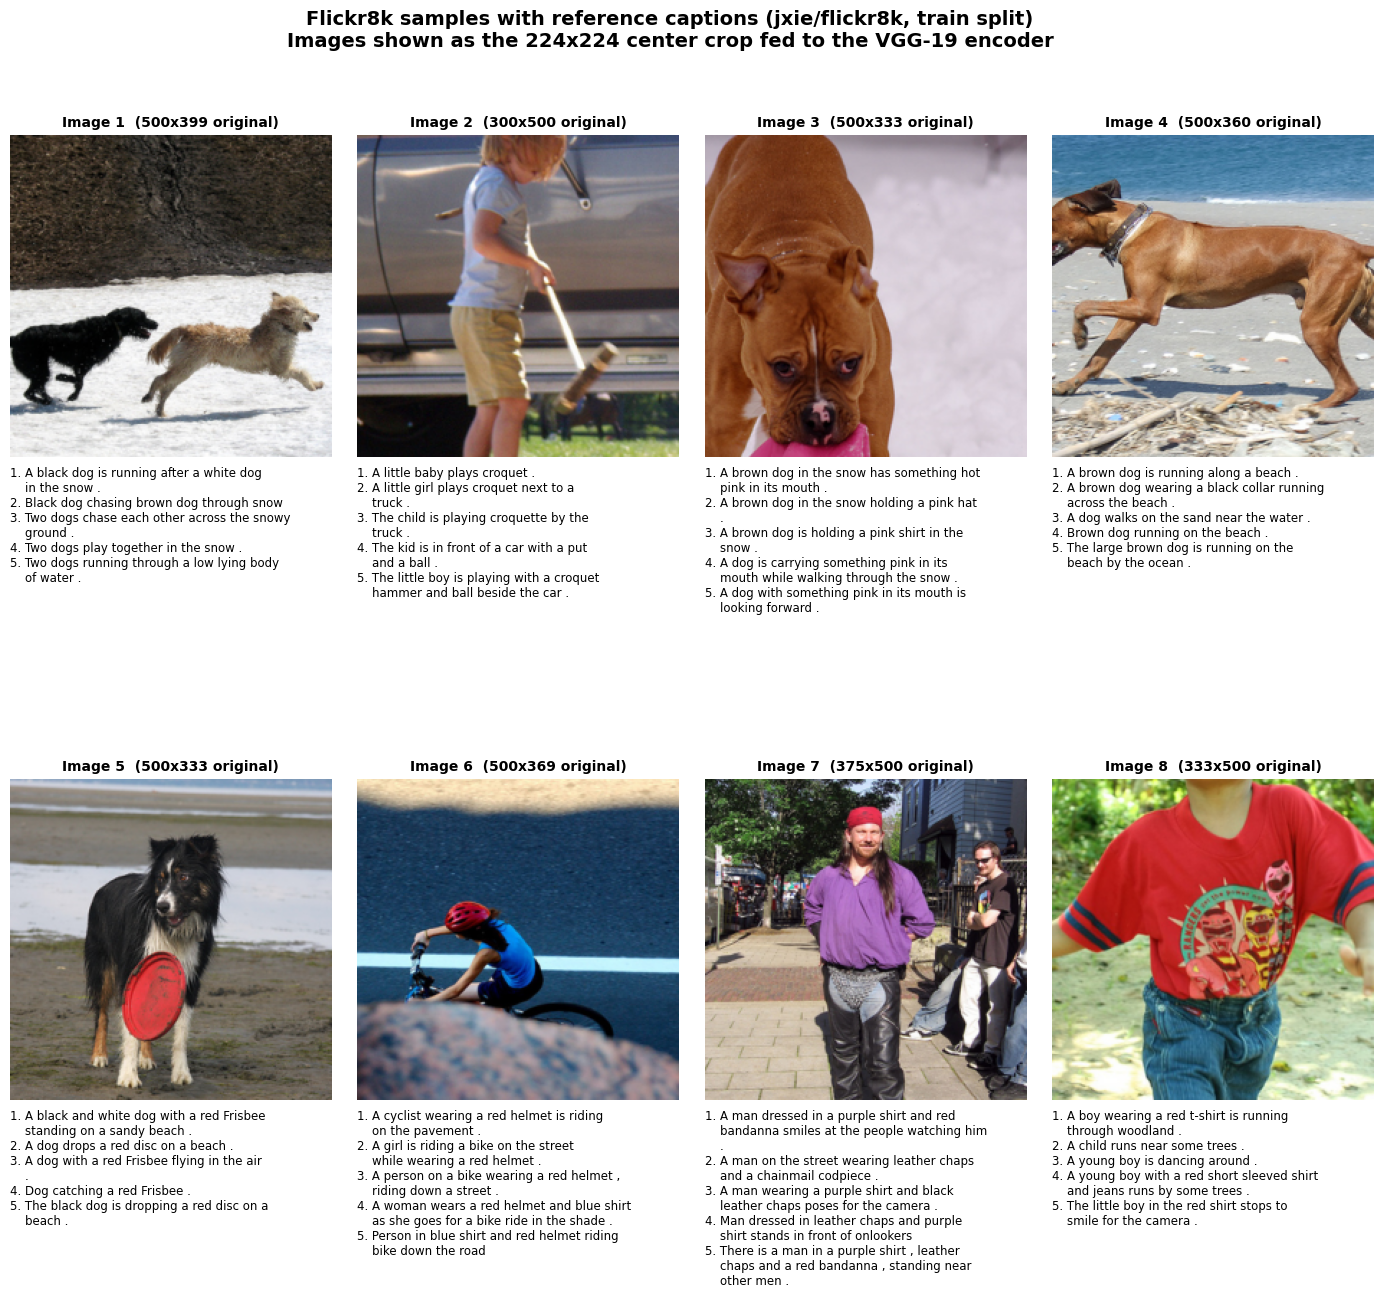

In [ ]:
# ============================================================================
# FLICKR8K DATASET VISUALIZATION — sample images with their reference captions
# ----------------------------------------------------------------------------
# Each Flickr8k image comes with 5 human-written reference captions (Sec 5.1).
# Images are shown as the 224x224 center crop (shorter side resized to 256)
# that is fed to the VGG-19 encoder (Sec 5.4), so you see what the model sees.
# ============================================================================


N_SHOW = 8             # number of images to display
N_COLS = 4             # grid columns
CAPTIONS_SHOWN = 5     # Flickr8k provides 5 references per image
SPLIT = "train"        # "train", "validation" or "test" (falls back to the first split)
WRAP_WIDTH = 42        # characters per caption line

# White theme with black text (same as the rest of the notebook)
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "text.color": "black", "axes.labelcolor": "black", "axes.edgecolor": "black",
    "xtick.color": "black", "ytick.color": "black", "axes.titlecolor": "black",
})

# ---- 1. Pick the dataset id (reuse the one loaded by the main cell if present)
if "DATASET_NAME" in globals():
    candidates = [DATASET_NAME]
else:
    candidates = ["jxie/flickr8k", "atasoglu/flickr8k-dataset", "Naveengo/flickr8k"]

# ---- 2. Robust extraction of the image and every caption column
def get_image_and_captions(example):
    img, caps = None, []
    for k, v in example.items():
        kl = k.lower()
        if img is None and isinstance(v, Image.Image):
            img = v
            continue
        if img is None and isinstance(v, dict) and v.get("bytes") is not None:
            img = Image.open(io.BytesIO(v["bytes"]))
            continue
        if "caption" in kl or kl in ("text", "sentences", "captions"):
            if isinstance(v, str):
                caps.append(v)
            elif isinstance(v, (list, tuple)):
                for c in v:
                    if isinstance(c, str):
                        caps.append(c)
                    elif isinstance(c, dict) and "raw" in c:
                        caps.append(c["raw"])
    caps = [c.strip() for c in caps if isinstance(c, str) and c.strip()]
    return img, caps

# ---- 3. Stream a few samples (only these images are downloaded)
samples, used_name = [], None
for name in candidates:
    try:
        ds = load_dataset(name, streaming=True)
        split = SPLIT if SPLIT in ds else list(ds.keys())[0]
        for ex in ds[split]:
            img, caps = get_image_and_captions(ex)
            if img is None or not caps:
                continue
            samples.append((img.convert("RGB"), caps[:CAPTIONS_SHOWN]))
            if len(samples) >= N_SHOW:
                break
        if samples:
            used_name = name
            break
    except Exception as e:
        print(f"Could not load {name}: {type(e).__name__}: {e}")

if not samples:
    raise RuntimeError("No Flickr8k samples could be loaded.")

print(f"Dataset: {used_name} | split: {split} | showing {len(samples)} images")
for i, (img, caps) in enumerate(samples):
    print(f"  Image {i + 1}: original size {img.size[0]}x{img.size[1]}, {len(caps)} captions")

# ---- 4. Plot: image grid with the reference captions under each image
model_view = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224)])

n_rows = int(np.ceil(len(samples) / N_COLS))
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(4.4 * N_COLS, 6.4 * n_rows), facecolor="white")
axes = np.array(axes).reshape(-1)

for ax in axes:
    ax.axis("off")

for i, (img, caps) in enumerate(samples):
    ax = axes[i]
    ax.imshow(np.array(model_view(img)))
    ax.set_title(f"Image {i + 1}  ({img.size[0]}x{img.size[1]} original)",
                 fontsize=10, color="black", fontweight="bold")
    lines = []
    for j, c in enumerate(caps, 1):
        wrapped = textwrap.wrap(c, WRAP_WIDTH)
        lines.append(f"{j}. " + "\n    ".join(wrapped))
    ax.text(0.0, -0.03, "\n".join(lines), transform=ax.transAxes, va="top", ha="left",
            fontsize=8.5, color="black")
    for s in ax.spines.values():
        s.set_color("black")

fig.suptitle(f"Flickr8k samples with reference captions ({used_name}, {split} split)\n"
             f"Images shown as the 224x224 center crop fed to the VGG-19 encoder",
             fontsize=14, color="black", fontweight="bold")
fig.subplots_adjust(hspace=0.75, wspace=0.08, top=0.9)

# ---- 5. Render in memory and display inline (no disk, no plt.show)
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=100, bbox_inches="tight", facecolor="white")
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

In [ ]:
# ----------------------------------------------------------------------------
# 3. TOKENIZATION & VOCABULARY  (1-of-K word encoding, Sec 3.1.1)
# ----------------------------------------------------------------------------
# Basic lowercase word tokenization, mirroring the paper's "basic tokenization".

# this function will break down (splits) a large block of langauge into discrete tokens.
def tokenize(text):
    # this line of code will return back the original alphabetic character
    # exluding the puncutation + numerical chara + whitespace
    return re.findall(r"[a-z]+", text.lower())


# padding: to equalize all different caption lengts in a mini-batch into one equal size (length)
# <start> will actaully trigger (start) the decoding generator process
# <end> will actually the termination (ending point) of the caption
# <unk> will actaully replace any unknown anonymous word into <unk>

PAD, START, END, UNK = "<pad>", "<start>", "<end>", "<unk>"

# count the frequencies of the words (tokens) to know how many times each token occured
word_counts = Counter(w for r in train_rows for c in r["captions"] for w in tokenize(c))


# this will actaully return back the actaul tokene
words = [w for w, c in word_counts.most_common() if c >= CONFIG["MIN_WORD_FREQ"]]
words = words[: CONFIG["MAX_VOCAB"] - 4]

# we need a functianality that convert indidces into actaul words
itos = [PAD, START, END, UNK] + words
stoi = {w: i for i, w in enumerate(itos)}
PAD_ID, START_ID, END_ID, UNK_ID = 0, 1, 2, 3 # 0 through 3 to reserve a place for those special tokens
K = len(itos)  # vocabulary size = number of output "classes"

def encode(tokens):
    ids = [stoi.get(w, UNK_ID) for w in tokens[: CONFIG["MAX_CAPTION_LEN"]]]
    return [START_ID] + ids + [END_ID]


# this function is the flipped ananlogy
# we have to provide it with indices and it will map them into actaul human-readable toknens
def decode(ids):
    out = []
    for i in ids:
        if i == END_ID:
            break
        if i not in (PAD_ID, START_ID): # rabbit, carrot, space, planet
            out.append(itos[i])
    return out

for r in train_rows + val_rows:
    r["tokens"] = [tokenize(c) for c in r["captions"]]

print(f"Vocabulary size K = {K} (paper uses 10,000 on the full dataset)")


Vocabulary size K = 1057 (paper uses 10,000 on the full dataset)


In [ ]:

# ----------------------------------------------------------------------------
# 4. ENCODER: FROZEN VGG-19 CONVOLUTIONAL FEATURES  (Sec 3.1.1, Sec 4.3)
# ----------------------------------------------------------------------------
# The paper uses the 14x14x512 map of VGG's 4th conv block "before max pooling"
# (conv5_4 + ReLU = vgg19.features[:36]) on a 224x224 center crop of an image
# whose shorter side is resized to 256 (Sec 5.4). The encoder is NOT
# fine-tuned, so we extract features once and cache them.

# this block of code will be our main images encoder
# that can process/encode an image and then a rich annotation vector

# Loading in our VGG Network architecture pretrained on imagenet dataset

vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)

# split our architecture from 0-th layer until 35-th layer
encoder_cnn = vgg.features[:36].eval().to(DEVICE)

# Freeze our Network architecture by disable pytorch from computing gradients on the paramter in those layer
for p in encoder_cnn.parameters():
    p.requires_grad_(False) # pytorch will not be able to actually optimze with weights/biases in these layers
del vgg # remaining part of the fully-connected layers

# defining how images are resized, normalized, pre-proccessed
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(), # convert the images into a pytorch tensor of shape (C, H, W) - float32 data type
    # to make sure the layers/weights/filter/kernels perform really well we have to make the images look
    # similar to how imagenet dataset is
    # by redefining the mean/STD of the dataset of Flicker8K datset into how image net is defined
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


display_tf = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224)])


# this function will be responsible for extracting feature from within images
@torch.no_grad() # JUST EXTRACTING FEATURES AND NOT LEARNING
def extract_features(rows, bs=32):
    feats = [] # append into the feature list later on
    for i in range(0, len(rows), bs): # this for loop will loop over all the batches one by one
        # a clever way to apply the transforms on a complete batch
        x = torch.stack([preprocess(r["image"]) for r in rows[i:i + bs]]).to(DEVICE)
        f = encoder_cnn(x)                    # (B, 512, 14, 14)
        f = f.flatten(2).transpose(1, 2)      # (B, 196, 512) = a = {a_1..a_L}
        feats.append(f.half().cpu())          # float16 cache to save memory
    return torch.cat(feats)

print("Extracting VGG-19 conv5_4 features ...")
t0 = time.time() # compute how long this operation takes

train_feats = extract_features(train_rows)

val_feats = extract_features(val_rows)
# these thumbnails are used just for showing/displaying purposes
val_thumbs = [np.array(display_tf(r["image"])) for r in val_rows]   # for attention plots
for r in train_rows + val_rows:
    r.pop("image")                            # free raw images
del encoder_cnn
if DEVICE.type == "cuda":
    torch.cuda.empty_cache() # clear out the memeory and speed up the operation
assert train_feats.shape[1:] == (CONFIG["NUM_REGIONS"], CONFIG["FEATURE_DIM"])
print(f"  train features {tuple(train_feats.shape)}, val features {tuple(val_feats.shape)} "
      f"({time.time() - t0:.1f}s)")


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 210MB/s]


Extracting VGG-19 conv5_4 features ...
  train features (400, 196, 512), val features (80, 196, 512) (4.9s)


In [ ]:
# ----------------------------------------------------------------------------
# 5. DATASET, LENGTH-BUCKET SAMPLER, DATALOADERS
# ----------------------------------------------------------------------------
# this block of code will package all the important components of building the data pipeline
class CaptionDataset(Dataset):
    """Each item = (annotation vectors a of one image, one encoded caption).
    Faithful to the paper: the model is trained on (image, caption) pairs and
    every image contributes all of its reference captions."""
    # the method __init__ will build the data pairs samples

    def __init__(self, feats, rows):
        self.feats = feats
        # <start> token
        # <end> token
        # <pad> token
        # every single image will occur five times
        # we have 5 decriptive caption per image
        # 400 * 5 = 2000 training images and captions by the end
        self.pairs = [(i, encode(toks)) for i, r in enumerate(rows) for toks in r["tokens"]]


    # DataLoader will need to know how many samples in a split
    def __len__(self):
        return len(self.pairs)


    # this method will return one sample upon request
    def __getitem__(self, idx):
        img_idx, ids = self.pairs[idx]
        # torch.long = torch.int64 the right data type for Cross Entropy LOss
        return self.feats[img_idx], torch.tensor(ids, dtype=torch.long), len(ids), img_idx


# this function will collect the several samples into  one batch
# massive dataset + massive deep learning models
# if you are training on one samples (then the gradients will be noisy)
# OOM (Out Of Memeory)
def collate(batch):
    feats, caps, lens, idxs = zip(*batch)
    # access the max total length
    T = max(lens)
    # pad our shorter caption into a unified sequncec length
    # torch.long=torch.int64
    padded = torch.full((len(caps), T), PAD_ID, dtype=torch.long)

    for i, c in enumerate(caps):
        padded[i, :len(c)] = c


    return torch.stack(feats), padded, torch.tensor(lens), torch.tensor(idxs)


# this class task is to group the identical caption lengts into buckets
# The man is playing a game of tennis (12 tokens)
# The rabbit is eating a carrort (7 tokens)
class LengthBucketBatchSampler(Sampler):
    """Sec 4.3: 'we randomly sample a length and retrieve a mini-batch of size 64
    of that length'. Captions are grouped by length so no batch wastes compute
    on padding; batches are then shuffled."""
    def __init__(self, lengths, batch_size, shuffle=True):

        self.buckets = defaultdict(list)


        for i, l in enumerate(lengths):
            self.buckets[l].append(i)

        self.bs, self.shuffle = batch_size, shuffle


    def __iter__(self):
        batches = [] # empty list

        for idxs in self.buckets.values():
            idxs = idxs[:] # copy the entire element lists
            # if we set shuffle to True, then Suffle
            if self.shuffle:
                random.shuffle(idxs)


            batches += [idxs[k:k + self.bs] for k in range(0, len(idxs), self.bs)]


        if self.shuffle:
            random.shuffle(batches)

        yield from batches # yeild samples form batch


    def __len__(self):
        return sum(math.ceil(len(v) / self.bs) for v in self.buckets.values())

# return one samples upon request
train_ds = CaptionDataset(train_feats, train_rows)
val_ds = CaptionDataset(val_feats, val_rows)

# Batchified style dataset
train_loader = DataLoader(
    train_ds, collate_fn=collate,
    batch_sampler=LengthBucketBatchSampler([len(p[1]) for p in train_ds.pairs], CONFIG["BATCH_SIZE"]))


val_loader = DataLoader(val_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=False, collate_fn=collate)

val_refs = [r["tokens"] for r in val_rows]   # multiple references per image for BLEU/METEOR

# ---- Sanity check ----
fb, cb, lb, ib = next(iter(train_loader))
print("\n=== SANITY CHECK ===")
print(f"Dataset: {DATASET_NAME}")
print(f"Train pairs: {len(train_ds)} ({len(train_rows)} images) | "
      f"Val pairs: {len(val_ds)} ({len(val_rows)} images)")
print(f"Batch features a: {tuple(fb.shape)}  (B, L=196, D=512)")
print(f"Batch captions y: {tuple(cb.shape)}  (B, T) — all same length via bucketing: "
      f"{lb.unique().tolist()}")
print(f"Target id range: [{int(cb.min())}, {int(cb.max())}] of K={K} vocabulary 'classes'")
print(f"Vocabulary preview: {itos[:25]}")
print(f"Example caption: '{' '.join(decode(cb[0].tolist()))}'")



=== SANITY CHECK ===
Dataset: jxie/flickr8k
Train pairs: 2000 (400 images) | Val pairs: 400 (80 images)
Batch features a: (64, 196, 512)  (B, L=196, D=512)
Batch captions y: (64, 16)  (B, T) — all same length via bucketing: [16]
Target id range: [1, 1053] of K=1057 vocabulary 'classes'
Vocabulary preview: ['<pad>', '<start>', '<end>', '<unk>', 'a', 'the', 'in', 'on', 'is', 'and', 'dog', 'with', 'of', 'man', 'two', 'boy', 'woman', 'are', 'black', 'white', 'red', 'at', 'brown', 'wearing', 'girl']
Example caption: 'a young lady is wearing bright pink sunglasses and sitting on a small trampoline'


In [ ]:
# ----------------------------------------------------------------------------
# 6. MODEL — implemented from the paper's equations
# ----------------------------------------------------------------------------
# this class builds the memory units (LSTM)
class PaperLSTMCell(nn.Module):
    """LSTM of Eq. 1-3 (following Zaremba et al., 2014), written from scratch.
    One affine map T_{D+m+n, n} on [E y_{t-1}; h_{t-1}; z_t] gives the
    input (i), forget (f), output (o) gates and input modulator (g)."""
    # this method will build the gates and affine linear transformation for our lstm cell
    def __init__(self, m, n, D):
        # m is the embedding dim
        # n is the our number of dims for the hidden layers
        # D is our feature dim
        super().__init__()
        # GPU hardware prefers to multiple on one big matrix multiplication
        # than 4 serpates matrices
        self.T = nn.Linear(m + n + D, 4 * n)

    def forward(self, Ey_prev, h_prev, c_prev, z):
        # Ey_prev the embedding of the previous word (token) (what did i just say)
        # h_prev the previous hidden state (the past memeory of what have i said so far)
        # c_prev the previous cell state (long term memory)
        # z is our current token
        gates = self.T(torch.cat([Ey_prev, h_prev, z], dim=1))   # Eq. 1
        # we have four gates in our LSTM implementation
        i, f, o, g = gates.chunk(4, dim=1)
        # apply non-linearity activation function to introduce complexity and non-linear curves
        i, f, o, g = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o), torch.tanh(g)

        c = f * c_prev + i * g                                   # Eq. 2
        h = o * torch.tanh(c)                                    # Eq. 3

        return h, c

# this block of code will implement the core Attention components
# at every time step the model is allowed to pay attnetion to whatever region inide the region

# this paper follows the style of Bhadanu attention model
class AttentionMLP(nn.Module):
    """f_att (Eq. 4): an MLP conditioned on h_{t-1}, followed by softmax (Eq. 5).
    e_ti = v^T tanh(W_a a_i + W_h h_{t-1})."""
    def __init__(self, D, n, att):
        super().__init__()
        # these three linear layer will form the small two-layer MLP attnetion
        self.W_a = nn.Linear(D, att) # map D to attention space
        self.W_h = nn.Linear(n, att) # maps our n to attention space
        self.v = nn.Linear(att, 1) # producing the final attentin score

    # the method forward will define the forward compuation of the model
    def forward(self, a_proj, h_prev):
        # attention alone is total linear operation
        e = self.v(torch.tanh(a_proj + self.W_h(h_prev).unsqueeze(1))).squeeze(-1)  # Eq. 4
        # convert/turn the attn score/coefficient into normalized prob dist
        return F.softmax(e, dim=1)                                                 # Eq. 5

# this class will assemble every single componenet into one class
class ShowAttendTell(nn.Module):

    # this method will actaully build the learnable layers
    # LSTM
    # Attention
    # Linear layers
    def __init__(self, K, m, n, D, att, mode="soft", dropout=0.5):
        super().__init__()
        self.mode = mode
        # pytorch will not compute gradeints for the padd pos
        # m= 128 convert every single token into a vector of size 128
        self.E = nn.Embedding(K, m, padding_idx=PAD_ID)          # E in R^{m x K}
        # n is our hidden space dim size
        self.f_init_h = nn.Linear(D, n)                          # Sec 3.1.2 init MLPs
        self.f_init_c = nn.Linear(D, n)

        # atten mechanims that can help the model pay attention on the regions in the image
        # that can can help the model onto generating the next word
        self.attention = AttentionMLP(D, n, att)
        # this f_beta layer is a simple learnable affine transformation that can weights
        self.f_beta = nn.Linear(n, 1)                            # gating scalar (Sec 4.2.1)
        self.cell = PaperLSTMCell(m, n, D) # contain memory units (C, H)
        self.L_h = nn.Linear(n, m, bias=False)                   # deep output (Eq. 7)
        self.L_z = nn.Linear(D, m, bias=False)
        self.L_o = nn.Linear(m, K)
        # dropout layer will dropout some feature/neurons stochastically using binary masks
        self.drop = nn.Dropout(dropout)

    def init_state(self, a):
        # LSTM must start with initital base line state
        # here we have to generator it manually

        # this line of code will return the average/mean of the annotation vectors
        mean_a = a.mean(dim=1)                                   # (1/L) sum_i a_i

        # this line of code will return the final activated initialiation C, H for our LSTM
        return torch.tanh(self.f_init_h(mean_a)), torch.tanh(self.f_init_c(mean_a))

    # to generator one word at a time
    def step(self, a, a_proj, y_prev, h, c, use_expect=None):
        # a is our annotation vector
        # a_projc is the projction layer of the annotation vector
        # y_prev the embedding of the previous word
        # h our previous hidden state
        # c our previous cell state
        # use_expect is our use expect flag True/False
        B = a.size(0) # batch size

        alpha = self.attention(a_proj, h)                        # alpha_t (B, L)

        # this is the entropy term of the attention tech
        entropy = -(alpha * torch.log(alpha + 1e-10)).sum(1)     # H[s] for diagnostics / hard

        # this is zeros tensor of the shape B batch size uploaded to device = device GPU/CPU
        log_p_s = torch.zeros(B, device=a.device)

        # if the attention tech is actaully soft (standard backpropgation)
        if self.mode == "soft":
            # Eq. 13 + Sec 4.2.1: phi = beta * sum_i alpha_i a_i
            beta = torch.sigmoid(self.f_beta(h)) # squash the values into the range (0, 1)
            z = beta * (alpha.unsqueeze(2) * a).sum(1)
        else:
            # if you would like to use Hard Attention then you have to check
            # wheater you are training or validation
            if self.training:
                # Eq. 8: s_t ~ Multinoulli(alpha); Eq. 9: z_t = sum_i s_ti a_i
                # consturct a prob dist with the attention weights
                dist = torch.distributions.Categorical(probs=alpha)
                # this line will sample (take) pick up a sample from the prob dist
                s = dist.sample()
                # the prob of selecting this sample from the prob dist (Log, prob, dist)
                log_p_s = dist.log_prob(s)
                # this is our z_sample value
                z_sample = a[torch.arange(B, device=a.device), s]
                # Sec 4.1: with prob 0.5 per image, use the expected value alpha

                z_expect = (alpha.unsqueeze(2) * a).sum(1)
                # this is a two-path condition
                # if this cond return true then choose Z-expect
                # otherwise return the z_sample value
                z = torch.where(use_expect.unsqueeze(1), z_expect, z_sample)

                # this line of code will return the final value based on a condition
                # it will reutrn a tensor of zeros in case we have cond true
                # other return a log prob of s
                log_p_s = torch.where(use_expect, torch.zeros_like(log_p_s), log_p_s)
            else:
                # Deterministic evaluation: attend to the most probable location
                s = alpha.argmax(1) # choose the highest prob of the probs by using argamx
                z = a[torch.arange(B, device=a.device), s]


        Ey = self.E(y_prev)
        # passing our combined inputs into the LSTM architecture
        h, c = self.cell(Ey, h, c, z)

        # this layer will project our learned feature vector
        # into a final logits space
        # that can contain rich probs values
        logits = self.L_o(self.drop(Ey + self.L_h(h) + self.L_z(z)))  # Eq. 7
        return logits, h, c, alpha, log_p_s, entropy

    # this method will define the forward compuatation of computation graph
    def forward(self, a, captions):
        """Teacher forcing: input y_{0..T-1}, predict y_{1..T}."""
        # retretive the batch size alongside the seq legnth
        B, T = captions.size(0), captions.size(1) - 1

        a_proj = self.attention.W_a(a)                           # precompute W_a a_i
        # produce the inital baseline states
        # hidden state + cell state
        h, c = self.init_state(a)

        use_expect = None # True/False
        # mode of atten can be both hard/soft attn
        if self.mode == "hard" and self.training:
            use_expect = torch.rand(B, device=a.device) < CONFIG["HARD_EXPECTATION_PROB"]
        L_, A_, P_, H_ = [], [], [], [] # init our baseline lists as empty objects
        # to pruduce a comprehensive sentence we have to call the method step for as many as we have
        for t in range(T):
            logits, h, c, alpha, lps, ent = self.step(a, a_proj, captions[:, t], h, c, use_expect)

            L_.append(logits); A_.append(alpha); P_.append(lps); H_.append(ent)

        # return a beautiful dictionary of all those values combined together
        return dict(logits=torch.stack(L_, 1), alphas=torch.stack(A_, 1),
                    log_p_s=torch.stack(P_, 1), entropy=torch.stack(H_, 1))

    # we will use a pytorch decorator
    # to turn off the gradients tracking operations
    @torch.no_grad()
    def generate(self, a, max_len):
        """Greedy autoregressive decoding; returns token ids and attention maps."""
        B = a.size(0) # need to access the batch size (formulate the tensors size later on)
        # pass annotation vector to the attention function to attend dynamically
        a_proj = self.attention.W_a(a)
        h, c = self.init_state(a)
        # create a pytorch tensor full of start_ID tokens
        # of the shape batch size
        # torch.long = torch.int64
        y = torch.full((B,), START_ID, dtype=torch.long, device=a.device)

        toks, alphas = [], []
        # cast the values into boolean values (True/False)
        done = torch.zeros(B, dtype=torch.bool, device=a.device)


        for _ in range(max_len):
            # logits is our mountain of unormalized score
            # normalized to  convert into a prob dist
            logits, h, c, alpha, _, _ = self.step(a, a_proj, y, h, c)
            y = logits.argmax(1)

            toks.append(y);
            alphas.append(alpha)

            done |= (y == END_ID)

            if done.all():
                break

        return torch.stack(toks, 1), torch.stack(alphas, 1)

model = ShowAttendTell(K, CONFIG["EMBED_DIM"], CONFIG["HIDDEN_DIM"], CONFIG["FEATURE_DIM"],
                       CONFIG["ATT_DIM"], mode=MODE, dropout=CONFIG["DROPOUT"]).to(DEVICE)


N_PARAMS = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel: Show, Attend and Tell ({MODE} attention) — "
      f"{N_PARAMS:,} trainable parameters (frozen VGG-19 excluded)")



Model: Show, Attend and Tell (soft attention) — 1,748,771 trainable parameters (frozen VGG-19 excluded)


In [ ]:
# ----------------------------------------------------------------------------
# 7. TRAINING OBJECTIVES
# ----------------------------------------------------------------------------
# Soft (Eq. 14): L_d = -log P(y|x) + lambda * sum_i (1 - sum_t alpha_ti)^2
#   We average the penalty over the L regions (equivalent to rescaling lambda)
#   so its magnitude is comparable to the per-token NLL.
# Hard (Sec 4.1): minimize -[log p(y|s,a) + lambda_r (log p(y|s,a) - b) log p(s|a)
#                            + lambda_e H[s]]   (REINFORCE with baseline b).

# this block of code will design what the model will actaully be trained to minimze

if MODE == "soft":
    # negative log-likelihood
    # ds_penalty - the penality to penalize larger weights
    # perpelexity is the metric to track during both modes
    LOSS_COMPONENTS = ["nll", "ds_penalty", "perplexity"]
else:
    # in case we have hard attention then go ahead and track
    # the following metrics
    LOSS_COMPONENTS = ["nll", "reinforce", "entropy", "perplexity"]

def compute_losses(out, targets, baseline=None, training=True):
    # out - the model's foward pass outputs (logits)
    # targets - the actaull dataset outputs
    # baseline: a moving-average of the baseline
    # training = True/False train mode

    # mask will mark every real tokens as 1 and any padding token as 0

    mask = (targets != PAD_ID).float() # convert the boolean value tensors into a floating point tensor

    ntok = mask.sum() # give us the total amount of elements/items in the list of captions

    # turning scores into log-probabilities (the required format)
    logp = F.log_softmax(out["logits"], dim=-1)
    # this line of code will gather all the dims across dim and then result into token log p
    tok_logp = logp.gather(2, targets.unsqueeze(2)).squeeze(2)

    # cross entorpy loss is also called log-loss
    # heavy penalities if the model produces high confidense errors (Rabbit -> 0.02) (0.98 -> boy) (0.999)
    # if the loss is zero that means the correct word has a perfect score (Rabbit -> 1.0)(0.000 -> boy) (0.0001)
    # the leading (-) will turn max into min
    nll = -(tok_logp * mask).sum() / ntok                       # per-token NLL

    seq_logp = (tok_logp * mask).sum(1)                         # log p(y | s, a) per caption

    # computing alpha sum t (attention weights of the model)
    alpha_sum_t = (out["alphas"] * mask.unsqueeze(2)).sum(1)    # sum_t alpha_ti  (B, L)

    # this code will compute the DS (1 - alpha_sum_T) - then average it out
    ds = ((1.0 - alpha_sum_t) ** 2).mean(1).mean()              # Eq. 14 penalty
    # every ent value that matches/correspond to the padding pos should be hidden
    ent = (out["entropy"] * mask).sum() / ntok                  # mean H[s]

    # if you use hard attention then you will have to compute REINFORCE
    # reinfoce is one of the most important metrics used for measuring the hard attention
    reinforce = torch.zeros((), device=targets.device)

    if MODE == "soft":
        # the final loss function combines
        # negative log-likelihood
        # lambda_DS penalty
        # DS (penalty term)
        total = nll + CONFIG["LAMBDA_DS"] * ds
    # if we are using hard attention + and also we are training
    elif training:
        # whenever you'd like to perform an operation that does not compute gradients
        # or you do not want other opeation to propgate those gradietns backward
        # then detach that operation form the computational graph
        b = seq_logp.detach().mean() if baseline is None else baseline

        # advantage reward of the hard attention
        # maximize the variational lower bound
        adv = seq_logp.detach() - b                             # (log p(y|s,a) - b)
        reinforce = -(CONFIG["LAMBDA_R"] * adv.unsqueeze(1) * out["log_p_s"] * mask).sum() / ntok

        # this is the final (eventual ) loss function used by hard attention
        total = nll + reinforce - CONFIG["LAMBDA_E"] * ent
    else: # if we are just evaluating the model
        total = nll   # at evaluation attention is deterministic; only NLL is defined

    # once we train the model and do a forward pass
    # when you compute the loss function it will return a rich dictionary full statistical metrics
    # ready to be visualized
    return dict(total=total, nll=nll, ds_penalty=ds, reinforce=reinforce,
                entropy=ent, perplexity=torch.exp(nll)), seq_logp.detach()


In [ ]:
# ----------------------------------------------------------------------------
# 8. EVALUATION METRICS: BLEU-1..4 (no brevity penalty) + METEOR
# ----------------------------------------------------------------------------

# The rabbit ate the carrot besides a tree
# The rabbit ate the carrot

# the puppy is running
# the dog is running

# the paper uses two main evaluation metrics
# 1. BLEU score (Bilingual Evaluation Understudy) (NLP) (0, 1) (0%, 100%)

# PRECISION
# BLEU places significant weights on "how much accurate the produced sentence is"

# 2. METEOR

# RECALL
# METERO places signifant weight on recall "how much of the original setence is captured  in the produced sentence"

# this python code will apply the core paractical implementation of BLEU / METEOR

# this function is a helper function
# 1-gram tokens
# 2-gram tokens
# n-gram tokens
def _ngrams(tokens, n):
    # couting the frequency of those grams
    # how often every single token appears in the seqeunce of captions
    return Counter(tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1))


# this funtion will be our main function to apply our BLEU (0, 1)
# this function implements a modified verison of BLEU
# no brevity penalty (disable the Brevity penalty term)
def corpus_bleu_no_bp(hyps, refs_list, max_n=4):
    """Corpus BLEU with clipped n-gram precision and NO brevity penalty,
    as reported in the paper (Sec 5.1)."""
    # clipped will be our max number of grams pos
    # total will be our total of max number of tokens
    clipped, total = [0] * max_n, [0] * max_n

    # a corpus-level BLUE score
    # hyp : a list of model-generated sequence of captions
    # refs: a list of ground-truth actaul sequence of captions
    for hyp, refs in zip(hyps, refs_list):

        for n in range(1, max_n + 1):
            hc = _ngrams(hyp, n) # utilitze that helper funtion that can extract the n-grams tokens
            max_ref = Counter() # the counter initializtion procedure

            for r in refs:
                # the pipe operation is element-wise operation that can extract the max over union
                max_ref |= _ngrams(r, n)          # element-wise max over references


                # if the best ref sentence contains 2 words as rabbit
                # but the produced sentence contain 5 words as rabbti

            clipped[n - 1] += sum(min(c, max_ref[g]) for g, c in hc.items())

            total[n - 1] += sum(hc.values()) # computint the total amount of occurneces in our h/c setences

    precisions = [(clipped[i] + 1e-9) / (total[i] + 1e-9) for i in range(max_n)]

    # finalizing the compuation of the BLEU
    return {f"bleu{N}": math.exp(sum(math.log(p) for p in precisions[:N]) / N)
            for N in range(1, max_n + 1)}


# Metric for Evaluation of Translation with Explicit Ordering
METEOR_AVAILABLE = False # this is flag var
try:
    import nltk # natural language toolkit
    # search over the database of words (Wordnet + OMw 1.4)
    for pkg in ("wordnet", "omw-1.4"):
        nltk.download(pkg, quiet=True)
    from nltk.translate.meteor_score import meteor_score as _nltk_meteor
    _nltk_meteor([["a", "dog"]], ["a", "dog"])
    METEOR_AVAILABLE = True # to use METEOR metrics
except Exception as e:
    print(f"METEOR unavailable ({type(e).__name__}); reporting BLEU only.")

# list of hypothese (a list of model-produce sentences)
# a list of refrences list (a list of actaul ground-truth tokens)
def corpus_meteor(hyps, refs_list):
    if not METEOR_AVAILABLE: # if we do not have that metrics
        return float("nan")
        # a list comprehension that can compuute the metrics on the fly
    return float(np.mean([_nltk_meteor(refs, hyp) if hyp else 0.0
                          for hyp, refs in zip(hyps, refs_list)]))

# Tokens used as "classes" in the per-class panels: most frequent target tokens in validation
val_target_counts = Counter(t for _, ids in val_ds.pairs for t in ids[1:])
TRACKED_IDS = [t for t, _ in val_target_counts.most_common(CONFIG["N_TRACKED_TOKENS"])]
CONF_IDS = TRACKED_IDS[: CONFIG["N_CONFUSION_TOKENS"]]

@torch.no_grad()
def evaluate_teacher_forced(model, loader):
    """Teacher-forced next-token evaluation: losses, token accuracy,
    per-token accuracy, token-confusion matrix, confidences."""
    model.eval()
    sums, nb = defaultdict(float), 0
    correct = total = 0
    pos = {t: i for i, t in enumerate(TRACKED_IDS)}
    cpos = {t: i for i, t in enumerate(CONF_IDS)}
    tok_corr, tok_tot = np.zeros(len(TRACKED_IDS)), np.zeros(len(TRACKED_IDS))
    cm = np.zeros((len(CONF_IDS), len(CONF_IDS) + 1))   # last column = "other"
    confs, flags = [], []
    for feats, caps, _, _ in loader:
        a, caps = feats.to(DEVICE).float(), caps.to(DEVICE)
        out = model(a, caps)
        targets = caps[:, 1:]
        losses, _ = compute_losses(out, targets, training=False)
        for k, v in losses.items():
            sums[k] += v.item()
        nb += 1
        probs = F.softmax(out["logits"], -1)
        conf, pred = probs.max(-1)
        m = targets != PAD_ID
        t_np, p_np, c_np = targets[m].cpu().numpy(), pred[m].cpu().numpy(), conf[m].cpu().numpy()
        correct += int((t_np == p_np).sum()); total += len(t_np)
        confs.append(c_np); flags.append(t_np == p_np)
        for ti, pi in zip(t_np, p_np):
            if ti in pos:
                tok_tot[pos[ti]] += 1
                tok_corr[pos[ti]] += float(ti == pi)
            if ti in cpos:
                cm[cpos[ti], cpos.get(pi, len(CONF_IDS))] += 1
    res = {k: v / nb for k, v in sums.items()}
    res["perplexity"] = math.exp(res["nll"])
    res["reinforce"] = float("nan") if MODE == "hard" else res["reinforce"]
    res.update(acc=correct / max(total, 1),
               tok_acc=tok_corr / np.maximum(tok_tot, 1),
               confusion=cm / np.maximum(cm.sum(1, keepdims=True), 1),
               confs=np.concatenate(confs), flags=np.concatenate(flags))
    return res

# this function will track the metrics while the model going through text and generating
@torch.no_grad()
def evaluate_generation(model, feats, refs, bs=40):
    """Greedy decoding on validation images, then BLEU-1..4 and METEOR."""
    model.eval()
    hyps, att_maps = [], []
    for i in range(0, len(feats), bs):
        a = feats[i:i + bs].to(DEVICE).float()
        toks, als = model.generate(a, CONFIG["MAX_CAPTION_LEN"] + 1)
        for b in range(toks.size(0)):
            words = decode(toks[b].tolist())
            hyps.append(words)
            att_maps.append(als[b, :len(words) + 1].cpu().numpy())
    scores = corpus_bleu_no_bp(hyps, refs)
    scores["meteor"] = corpus_meteor(hyps, refs)
    return hyps, att_maps, scores



In [ ]:

# ----------------------------------------------------------------------------
# 9. TRAINING LOOP (5 epochs, RMSProp, model selection by validation BLEU)
# ----------------------------------------------------------------------------
# we are using RMSProp optimizer and set the learning rate = lr of the config
optimizer = torch.optim.RMSprop(model.parameters(), lr=CONFIG["LR"])
history = defaultdict(list) # we have a dictionry to store mtrics one by one
# these are the initial baseline value
# later during training loop we can adjust them to them here
best_bleu4, best_epoch, best_state = -1.0, 0, None
baseline = None # value that can be update the moving average of the baseline

print(f"\nTraining for {CONFIG['EPOCHS']} epochs ({MODE} attention) ...")
for epoch in range(1, CONFIG["EPOCHS"] + 1):
    # dropout layer
    model.train() # set the model into training mode

    t0 = time.time() # how long each training epoch takes (duration)

    sums, nb, correct, total = defaultdict(float), 0, 0, 0
    # this for loop is yeilding getting the bathes one by one
    for feats, caps, _, _ in train_loader:
        # the model should pay attention to the imgae regions and align them
        # with the caption string of tokens
        # to make our dataset and also the model on the same device (devcie mismatch errors)
        a, caps = feats.to(DEVICE).float(), caps.to(DEVICE)
        # out is a dictionary of ouputs (logits + attnetion alpha weights + many more outputs)
        out = model(a, caps) # show attend, tell model (Image Encoer + LSTM architecture + Attention)

        targets = caps[:, 1:]
        # compute loss function value
        losses, seq_logp = compute_losses(out, targets, baseline=baseline, training=True)
        # making optimization step
        optimizer.zero_grad() # clear out the prev gradients of the steps
        losses["total"].backward() # compute gradints based on the tota list w.r.t the weights/baises

        # clip the large gradients and normalation
        # prevent gradients explosion (by clipping them)
        nn.utils.clip_grad_norm_(model.parameters(), CONFIG["GRAD_CLIP"])
        optimizer.step() # one optimizer step to improve the weights/bises

        if MODE == "hard":   # moving-average baseline b_k (Sec 4.1)
            m_logp = seq_logp.mean().item()
            # the baseline used in the hard attention to compute the baseline value
            baseline = m_logp if baseline is None else \
                CONFIG["BASELINE_DECAY"] * baseline + (1 - CONFIG["BASELINE_DECAY"]) * m_logp

        for k, v in losses.items():
            sums[k] += v.item() # increment by the value item
        nb += 1 # incremen the batch size by one
        # disable the tracking of gradeitns
        with torch.no_grad():
            m = targets != PAD_ID
            # compute the accuracy value
            correct += int((out["logits"].argmax(-1)[m] == targets[m]).sum())
            # return the total amount of samples
            total += int(m.sum())

    train_res = {k: v / nb for k, v in sums.items()}
    train_res["perplexity"] = math.exp(train_res["nll"])
    val_res = evaluate_teacher_forced(model, val_loader)
    # compute the metrics on-the-fly
    _, _, gen_scores = evaluate_generation(model, val_feats, val_refs)

    history["train_total"].append(train_res["total"])
    history["val_total"].append(val_res["total"])
    for comp in ["nll", "ds_penalty", "reinforce", "entropy", "perplexity"]:
        history[f"train_{comp}"].append(train_res[comp])
        history[f"val_{comp}"].append(val_res[comp])
    history["train_acc"].append(correct / max(total, 1))
    history["val_acc"].append(val_res["acc"])
    for k, v in gen_scores.items():
        history[k].append(v)
    history["tok_acc_epochs"].append(val_res["tok_acc"])

    # Early stopping / model selection on validation BLEU (Sec 4.3)
    # in case we have reached a new metrics value
    # go ahead and update our variables to reflect the computed metrics
    if gen_scores["bleu4"] > best_bleu4:
        best_bleu4, best_epoch = gen_scores["bleu4"], epoch
        best_state = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch}/{CONFIG['EPOCHS']} | train loss {train_res['total']:.3f} "
          f"(NLL {train_res['nll']:.3f}) | val NLL {val_res['nll']:.3f} "
          f"ppl {val_res['perplexity']:.1f} | tok-acc {val_res['acc']:.3f} | "
          f"BLEU-1/4 {gen_scores['bleu1']*100:.1f}/{gen_scores['bleu4']*100:.1f} | "
          f"METEOR {gen_scores['meteor']*100:.1f} | {time.time()-t0:.1f}s")


Training for 50 epochs (soft attention) ...
Epoch 1/50 | train loss 6.126 (NLL 5.237) | val NLL 4.185 ppl 65.7 | tok-acc 0.245 | BLEU-1/4 26.1/1.7 | METEOR 19.0 | 5.7s
Epoch 2/50 | train loss 5.322 (NLL 4.435) | val NLL 3.902 ppl 49.5 | tok-acc 0.275 | BLEU-1/4 57.1/10.8 | METEOR 25.4 | 1.9s
Epoch 3/50 | train loss 5.030 (NLL 4.143) | val NLL 3.766 ppl 43.2 | tok-acc 0.278 | BLEU-1/4 63.6/16.1 | METEOR 24.4 | 1.8s
Epoch 4/50 | train loss 4.801 (NLL 3.912) | val NLL 3.652 ppl 38.6 | tok-acc 0.304 | BLEU-1/4 54.8/13.4 | METEOR 26.8 | 1.9s
Epoch 5/50 | train loss 4.625 (NLL 3.735) | val NLL 3.648 ppl 38.4 | tok-acc 0.292 | BLEU-1/4 59.6/16.6 | METEOR 26.5 | 1.9s
Epoch 6/50 | train loss 4.472 (NLL 3.581) | val NLL 3.542 ppl 34.5 | tok-acc 0.311 | BLEU-1/4 49.4/9.9 | METEOR 26.9 | 1.9s
Epoch 7/50 | train loss 4.291 (NLL 3.400) | val NLL 3.533 ppl 34.2 | tok-acc 0.316 | BLEU-1/4 48.8/11.5 | METEOR 27.1 | 1.9s
Epoch 8/50 | train loss 4.166 (NLL 3.274) | val NLL 3.537 ppl 34.4 | tok-acc 0.302

In [ ]:
# ----------------------------------------------------------------------------
# 10. FINAL EVALUATION WITH THE BEST (BLEU-SELECTED) MODEL
# ----------------------------------------------------------------------------
model.load_state_dict(best_state) # load the model back in from the weights of the model checkpoints
final_tf = evaluate_teacher_forced(model, val_loader) # evaluate the model based on teach forcing
final_hyps, final_atts, final_scores = evaluate_generation(model, val_feats, val_refs)

print(f"\n=== FINAL RESULTS (best epoch {best_epoch}) ===")
for N in range(1, 5):
    print(f"BLEU-{N}: {final_scores[f'bleu{N}']*100:.2f}")
print(f"METEOR: {final_scores['meteor']*100:.2f}")
print(f"Teacher-forced token accuracy: {final_tf['acc']:.3f} | perplexity: {final_tf['perplexity']:.2f}")

# these the metircs of the best model checkpoints


=== FINAL RESULTS (best epoch 5) ===
BLEU-1: 59.62
BLEU-2: 39.64
BLEU-3: 24.81
BLEU-4: 16.55
METEOR: 26.46
Teacher-forced token accuracy: 0.292 | perplexity: 38.41


In [ ]:
# ----------------------------------------------------------------------------
# 11. PREDICTION PIPELINE — qualitative examples (decoded words)
# ----------------------------------------------------------------------------
print("\n=== SAMPLE PREDICTIONS (greedy decoding) ===")
for i in range(6):
    print(f"\n[Val image {i}]")
    print(f"  Reference 1: {' '.join(val_refs[i][0])}")
    if len(val_refs[i]) > 1:
        print(f"  Reference 2: {' '.join(val_refs[i][1])}")
    print(f"  Predicted  : {' '.join(final_hyps[i]) or '<empty>'}")


# we have trained the mdoel 400 images as training
# we have used 80 validation images for evaluation puprpses


=== SAMPLE PREDICTIONS (greedy decoding) ===

[Val image 0]
  Reference 1: the boy laying face down on a skateboard is being pushed along the ground by another boy
  Reference 2: two girls play on a skateboard in a courtyard
  Predicted  : a man in a <unk>

[Val image 1]
  Reference 1: a boy in a blue top is jumping off some rocks in the woods
  Reference 2: a boy jumps off a tan rock
  Predicted  : a man in a <unk>

[Val image 2]
  Reference 1: a lady walking her dog through an obstacle course while other people are in the background
  Reference 2: a small tan and white dog and trainer running an obstacle course
  Predicted  : a dog is running through a <unk>

[Val image 3]
  Reference 1: a big black dog jumps in the air to catch the tennis ball in his mouth
  Reference 2: a dog looks at another dog catching a ball in the air
  Predicted  : a black dog is running through a <unk>

[Val image 4]
  Reference 1: two woman climbing rocks around the ocean
  Reference 2: two women are climb

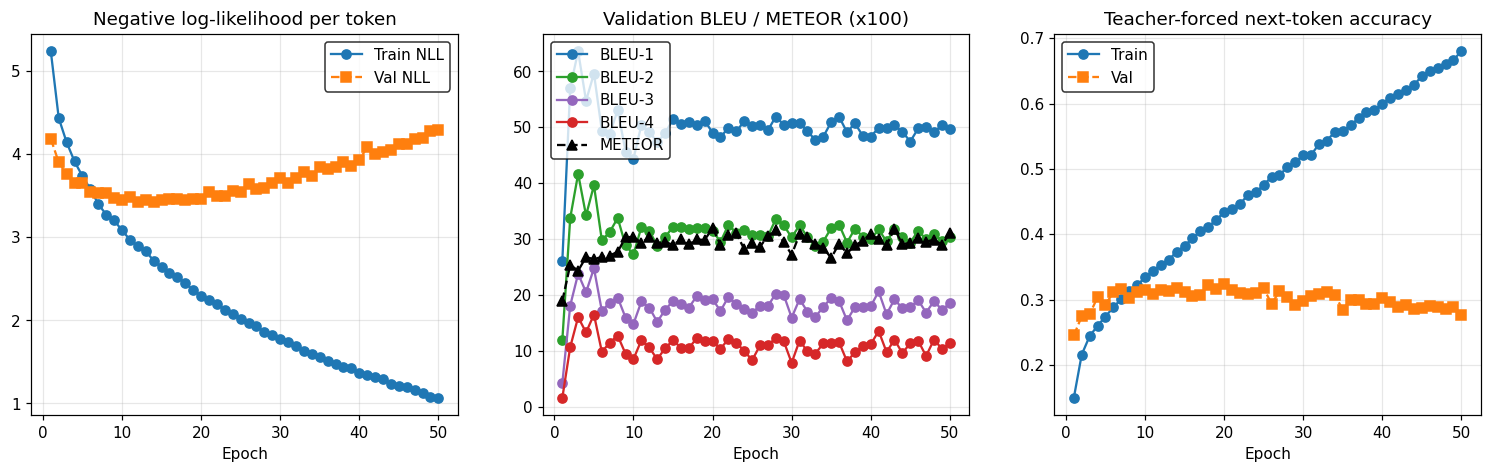

In [ ]:
# ----------------------------------------------------------------------------
# 12. STANDARD EDUCATIONAL PLOTS
# ----------------------------------------------------------------------------
epochs = np.arange(1, CONFIG["EPOCHS"] + 1)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
axes[0].plot(epochs, history["train_nll"], "o-", color="tab:blue", label="Train NLL")
axes[0].plot(epochs, history["val_nll"], "s--", color="tab:orange", label="Val NLL")
axes[0].set_title("Negative log-likelihood per token"); axes[0].set_xlabel("Epoch"); axes[0].legend()
for N, col in zip(range(1, 5), ["tab:blue", "tab:green", "tab:purple", "tab:red"]):
    axes[1].plot(epochs, np.array(history[f"bleu{N}"]) * 100, "o-", color=col, label=f"BLEU-{N}")
if METEOR_AVAILABLE:
    axes[1].plot(epochs, np.array(history["meteor"]) * 100, "k^--", label="METEOR")
axes[1].set_title("Validation BLEU / METEOR (x100)"); axes[1].set_xlabel("Epoch"); axes[1].legend()
axes[2].plot(epochs, history["train_acc"], "o-", color="tab:blue", label="Train")
axes[2].plot(epochs, history["val_acc"], "s--", color="tab:orange", label="Val")
axes[2].set_title("Teacher-forced next-token accuracy"); axes[2].set_xlabel("Epoch"); axes[2].legend()
for ax in axes:
    ax.grid(alpha=0.3); style_ax(ax)
show_fig(fig)

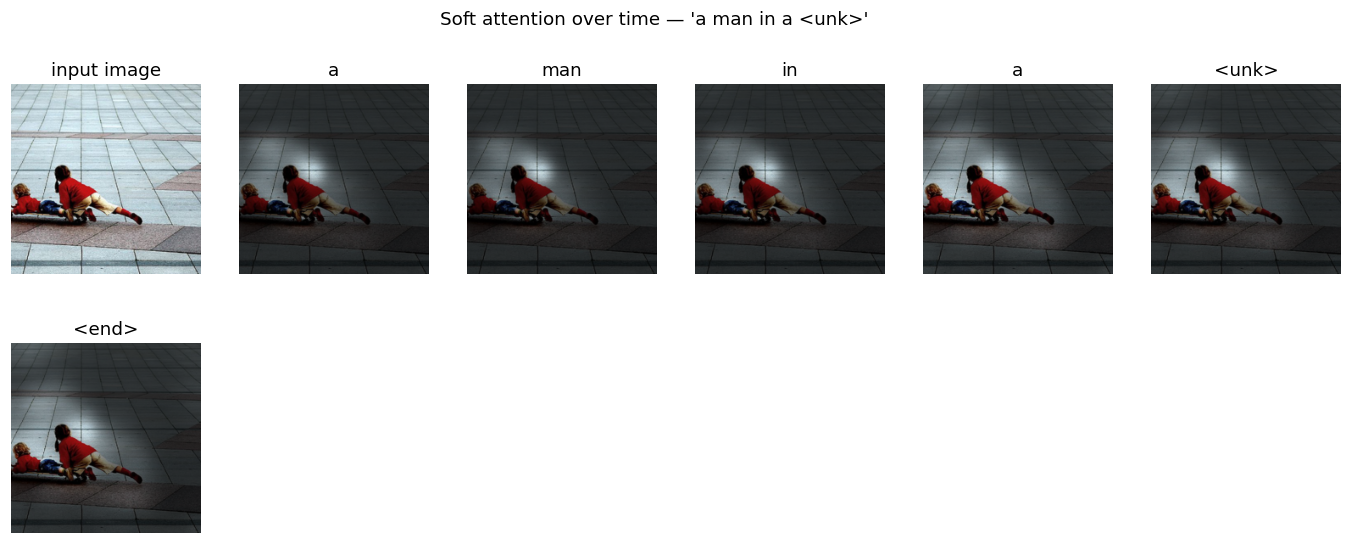

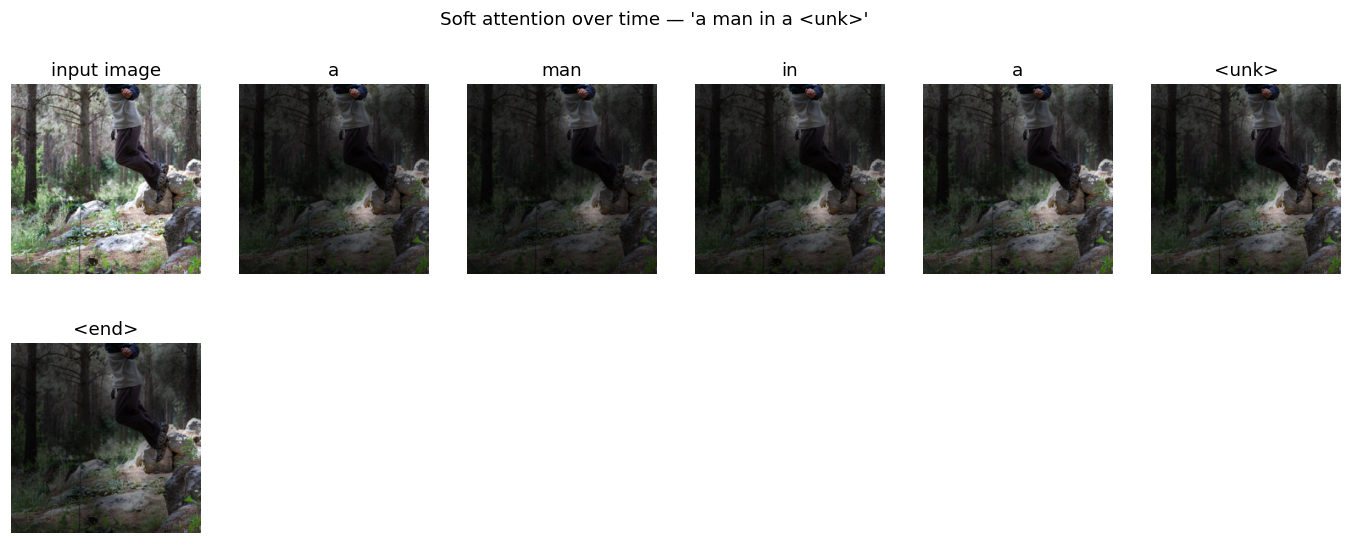

In [ ]:
# Attention visualization (paper Fig. 2/3, Sec 5.4): weights upsampled by
# 2^4 = 16 and smoothed with a Gaussian filter. White = attended region.
def upsample_attention(alpha_vec):
    att = alpha_vec.reshape(14, 14)
    att = np.kron(att, np.ones((16, 16)))
    att = gaussian_filter(att, sigma=8)
    return att / (att.max() + 1e-8)

for img_i in range(2):
    words = final_hyps[img_i] + ["<end>"]
    atts = final_atts[img_i]
    n = min(len(words), len(atts), 11)
    ncols = 6
    nrows = math.ceil((n + 1) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.6 * ncols, 2.8 * nrows))
    axes = np.array(axes).reshape(-1)
    axes[0].imshow(val_thumbs[img_i]); axes[0].set_title("input image")
    for j in range(n):
        att = upsample_attention(atts[j])
        overlay = np.clip(val_thumbs[img_i] * (0.2 + 0.8 * att[..., None]), 0, 255).astype(np.uint8)
        axes[j + 1].imshow(overlay)
        axes[j + 1].set_title(words[j])
    for ax in axes:
        ax.axis("off"); style_ax(ax)
    fig.suptitle(f"{MODE.capitalize()} attention over time — '{' '.join(final_hyps[img_i])}'",
                 color="black")
    show_fig(fig)


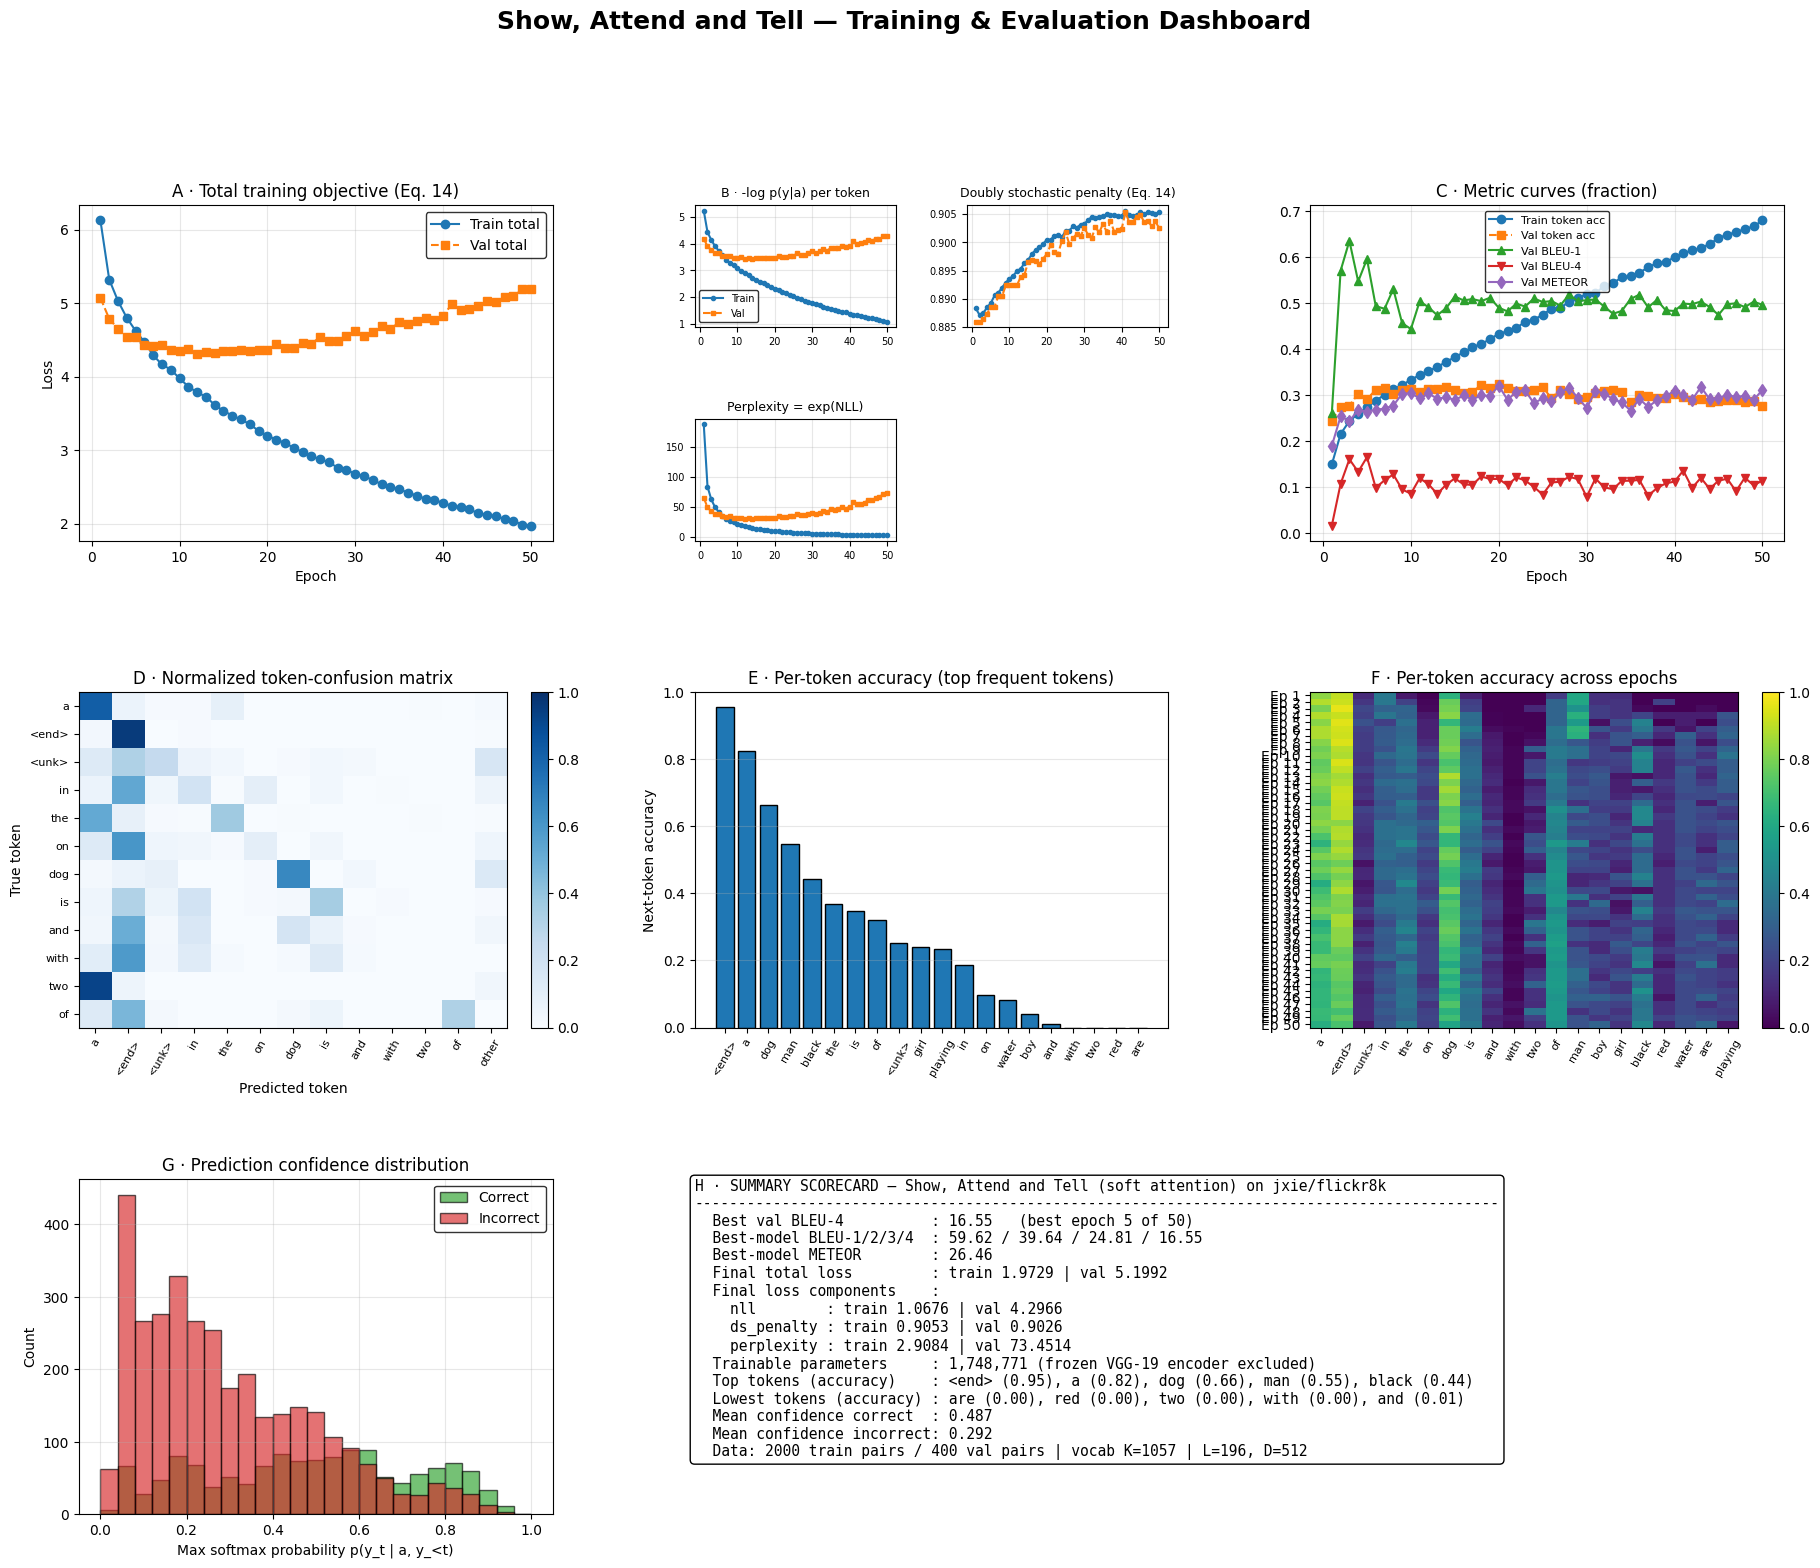

In [ ]:

# ----------------------------------------------------------------------------
# 13. SUMMARY DASHBOARD (final visualization)
# ----------------------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "text.color": "black", "axes.labelcolor": "black", "axes.edgecolor": "black",
    "xtick.color": "black", "ytick.color": "black", "axes.titlecolor": "black",
    "legend.facecolor": "white", "legend.edgecolor": "black", "legend.labelcolor": "black",
})

tok_names = [itos[t] for t in TRACKED_IDS]
conf_names = [itos[t] for t in CONF_IDS]

fig = plt.figure(figsize=(22, 17), facecolor="white")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.3)

# Panel A — total objective (Eq. 14 for soft; REINFORCE rule for hard)
axA = fig.add_subplot(gs[0, 0])
axA.plot(epochs, history["train_total"], "o-", color="tab:blue", label="Train total")
axA.plot(epochs, history["val_total"], "s--", color="tab:orange",
         label="Val total" + (" (NLL only)" if MODE == "hard" else ""))
axA.set_title("A · Total training objective"
              + (" (Eq. 14)" if MODE == "soft" else " (Sec 4.1)"))
axA.set_xlabel("Epoch"); axA.set_ylabel("Loss"); axA.legend(); axA.grid(alpha=0.3); style_ax(axA)

# Panel B — one sub-plot per loss component defined by the paper
comp_titles = {"nll": "-log p(y|a) per token", "ds_penalty": "Doubly stochastic penalty (Eq. 14)",
               "reinforce": "REINFORCE term (Eq. 12)", "entropy": "Attention entropy H[s]",
               "perplexity": "Perplexity = exp(NLL)"}
nB = len(LOSS_COMPONENTS)
subB = gs[0, 1].subgridspec(math.ceil(nB / 2), 2, hspace=0.75, wspace=0.35)
for j, comp in enumerate(LOSS_COMPONENTS):
    ax = fig.add_subplot(subB[j // 2, j % 2])
    ax.plot(epochs, history[f"train_{comp}"], "o-", color="tab:blue", ms=3, label="Train")
    vals = np.array(history[f"val_{comp}"], dtype=float)
    if not np.all(np.isnan(vals)):
        ax.plot(epochs, vals, "s--", color="tab:orange", ms=3, label="Val")
    ax.set_title(("B · " if j == 0 else "") + comp_titles[comp], fontsize=9)
    ax.tick_params(labelsize=7); ax.grid(alpha=0.3)
    if j == 0:
        ax.legend(fontsize=7)
    style_ax(ax)

# Panel C — paper metrics (BLEU, METEOR) + token accuracy
axC = fig.add_subplot(gs[0, 2])
axC.plot(epochs, history["train_acc"], "o-", color="tab:blue", label="Train token acc")
axC.plot(epochs, history["val_acc"], "s--", color="tab:orange", label="Val token acc")
axC.plot(epochs, history["bleu1"], "^-", color="tab:green", label="Val BLEU-1")
axC.plot(epochs, history["bleu4"], "v-", color="tab:red", label="Val BLEU-4")
if METEOR_AVAILABLE:
    axC.plot(epochs, history["meteor"], "d-", color="tab:purple", label="Val METEOR")
axC.set_title("C · Metric curves (fraction)"); axC.set_xlabel("Epoch")
axC.legend(fontsize=8); axC.grid(alpha=0.3); style_ax(axC)

# Panel D — token-confusion matrix. Captioning is generation, so the closest
# analogue of a class confusion matrix is: true next token (row) vs. the
# model's teacher-forced prediction (column) over the most frequent tokens.
axD = fig.add_subplot(gs[1, 0])
im = axD.imshow(final_tf["confusion"], cmap="Blues", vmin=0, vmax=1, aspect="auto")
axD.set_xticks(range(len(conf_names) + 1)); axD.set_xticklabels(conf_names + ["other"], rotation=60, fontsize=8)
axD.set_yticks(range(len(conf_names))); axD.set_yticklabels(conf_names, fontsize=8)
axD.set_xlabel("Predicted token"); axD.set_ylabel("True token")
axD.set_title("D · Normalized token-confusion matrix")
cb = fig.colorbar(im, ax=axD, fraction=0.046)
cb.ax.tick_params(colors="black")
style_ax(axD)

# Panel E — per-token accuracy (tokens = output "classes")
axE = fig.add_subplot(gs[1, 1])
order = np.argsort(-final_tf["tok_acc"])
axE.bar(range(len(order)), final_tf["tok_acc"][order], color="tab:blue", edgecolor="black")
axE.set_xticks(range(len(order))); axE.set_xticklabels([tok_names[i] for i in order], rotation=60, fontsize=8)
axE.set_ylim(0, 1); axE.set_ylabel("Next-token accuracy")
axE.set_title("E · Per-token accuracy (top frequent tokens)"); axE.grid(axis="y", alpha=0.3); style_ax(axE)

# Panel F — epoch-wise per-token accuracy heatmap
axF = fig.add_subplot(gs[1, 2])
heat = np.stack(history["tok_acc_epochs"])
imF = axF.imshow(heat, cmap="viridis", vmin=0, vmax=1, aspect="auto")
axF.set_yticks(range(len(epochs))); axF.set_yticklabels([f"Ep {e}" for e in epochs])
axF.set_xticks(range(len(tok_names))); axF.set_xticklabels(tok_names, rotation=60, fontsize=8)
axF.set_title("F · Per-token accuracy across epochs")
cbF = fig.colorbar(imF, ax=axF, fraction=0.046)
cbF.ax.tick_params(colors="black")
style_ax(axF)

# Panel G — confidence (max softmax probability) for correct vs incorrect tokens
axG = fig.add_subplot(gs[2, 0])
confs, flags = final_tf["confs"], final_tf["flags"]
bins = np.linspace(0, 1, 26)
axG.hist(confs[flags], bins=bins, alpha=0.65, color="tab:green", edgecolor="black", label="Correct")
axG.hist(confs[~flags], bins=bins, alpha=0.65, color="tab:red", edgecolor="black", label="Incorrect")
axG.set_xlabel("Max softmax probability p(y_t | a, y_<t)"); axG.set_ylabel("Count")
axG.set_title("G · Prediction confidence distribution"); axG.legend(); axG.grid(alpha=0.3); style_ax(axG)

# Panel H — text scorecard
axH = fig.add_subplot(gs[2, 1:])
axH.axis("off")
top = [f"{tok_names[i]} ({final_tf['tok_acc'][i]:.2f})" for i in order[:5]]
low = [f"{tok_names[i]} ({final_tf['tok_acc'][i]:.2f})" for i in order[::-1][:5]]
final_losses = "\n".join(f"    {c:<11}: train {history[f'train_{c}'][-1]:.4f} | "
                         f"val {history[f'val_{c}'][-1]:.4f}" for c in LOSS_COMPONENTS)
mean_c = confs[flags].mean() if flags.any() else float("nan")
mean_i = confs[~flags].mean() if (~flags).any() else float("nan")
txt = (
    f"H · SUMMARY SCORECARD — Show, Attend and Tell ({MODE} attention) on {DATASET_NAME}\n"
    f"{'-' * 92}\n"
    f"  Best val BLEU-4          : {best_bleu4 * 100:.2f}   (best epoch {best_epoch} of {CONFIG['EPOCHS']})\n"
    f"  Best-model BLEU-1/2/3/4  : " + " / ".join(f"{final_scores[f'bleu{N}'] * 100:.2f}" for N in range(1, 5)) + "\n"
    f"  Best-model METEOR        : {final_scores['meteor'] * 100:.2f}\n"
    f"  Final total loss         : train {history['train_total'][-1]:.4f} | val {history['val_total'][-1]:.4f}\n"
    f"  Final loss components    :\n{final_losses}\n"
    f"  Trainable parameters     : {N_PARAMS:,} (frozen VGG-19 encoder excluded)\n"
    f"  Top tokens (accuracy)    : {', '.join(top)}\n"
    f"  Lowest tokens (accuracy) : {', '.join(low)}\n"
    f"  Mean confidence correct  : {mean_c:.3f}\n"
    f"  Mean confidence incorrect: {mean_i:.3f}\n"
    f"  Data: {len(train_ds)} train pairs / {len(val_ds)} val pairs | vocab K={K} | L=196, D=512"
)
axH.text(0.0, 1.0, txt, va="top", ha="left", family="monospace", fontsize=10.5, color="black",
         bbox=dict(boxstyle="round", facecolor="white", edgecolor="black"))

fig.suptitle("Show, Attend and Tell — Training & Evaluation Dashboard", fontsize=18,
             fontweight="bold", color="black", y=0.995)

buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=100, bbox_inches="tight", facecolor="white")
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))